In [164]:
import pandas as pd
import numpy as np
from build_utils import get_universalization_summary, get_outcome_metrics, build_design_matrix
from analysis_utils import regression_xy, plot_simple_regression, compare_models, fit_ols, subset_design

OUTCOME_COLS = [
    "aggregate_welfare",
    "inequality",
    "cardinal_harm",
    "ordinal_harm_blind",
    "gini",
]
UNIV_COLS = [f"univ_{c}" for c in OUTCOME_COLS]

In [3]:
# Retrieve per-scenario outcome metrics
out = get_outcome_metrics(recompute=False) # set to True to rebuild from completion times

# Retrieve experimental data
xp_file = "cross_cultural_pilot_summary.csv"
xp = pd.read_csv(f"../data/experimental/{xp_file}")

In [15]:
# Dec 17 mix in all run types and noise (actually tempereature..) values
# ----------------------------
# 1) Runs: base + noise variants
# ----------------------------
NOISE_VALUES = [0.0001, 0.001, 0.01, 0.1, 0.3, 1.0]

BASE_RUN_TYPES = ["kwon2023", "level-0", "level-1"]
RUNS_WITH_NOISE = {"level-0", "level-1"}  # only these get _noise-...

def noise_tag(noise: float) -> str:
    # matches your existing run naming (e.g., 1.0 stays "1.0")
    return str(noise)

def iter_run_strings(base_run: str):
    yield base_run
    if base_run in RUNS_WITH_NOISE:
        for noise in NOISE_VALUES:
            yield f"{base_run}_noise-{noise_tag(noise)}"

ALL_RUN_STRINGS = [r for base in BASE_RUN_TYPES for r in iter_run_strings(base)]


# ----------------------------
# 2) Subset specs (one place)
# ----------------------------
MAPS_Z = ["no_line_1", "no_line_3", "no_line_A", "maybe_5", "no_line_C", "no_line_2",
          "yes_line_7", "new_maybe_2", "maybe_6", "no_line_D", "yes_line_9", "7esque", "yes_line_8"]
MAPS_D = ["new_maybe_5", "yes_line_9", "yes_line_10", "yes_line_8"]
MAPS_SD = ["new_maybe_5", "yes_line_10", "yes_line_8"]
MAPS_REL = ["new_maybe_2", "no_line_D", "new_maybe_3"]
MAPS_REL_2 = ["no_line_1", "no_line_3", "maybe_4", "maybe_5", "yes_line_9", "yes_line_8", "yes_line_10"]

SUBSETS = {
    "all": {},

    # by map type
    "yes":   {"map_types": ["yes_line"]},
    "no":    {"map_types": ["no_line"]},
    "maybe": {"map_types": ["maybe"]},

    # by subtype
    "yes_number": {"map_subtypes": ["yes_line_number"]},
    "yes_letter": {"map_subtypes": ["yes_line_letter"]},
    "no_number":  {"map_subtypes": ["no_line_number"]},
    "no_letter":  {"map_subtypes": ["no_line_letter"]},
    "maybe_maybe": {"map_subtypes": ["maybe"]},
    "new_maybe":  {"map_subtypes": ["new_maybe"]},
    "esque":      {"map_subtypes": ["esque"]},

    # by condition
    "worse_cut":  {"conditions": ["1cut_bad", "1cut_badder"]},
    "normal_cut": {"conditions": ["1cut"]},
    "bad_cut":    {"conditions": ["1cut_bad"]},
    "badder_cut": {"conditions": ["1cut_badder"]},

    # by hand-picked map sets
    "maps_z":   {"maps": MAPS_Z},
    "maps_d":   {"maps": MAPS_D},
    "maps_rel1": {"maps": MAPS_REL},
    "maps_rel2": {"maps": MAPS_REL_2},
    "maps_rel3": {"maps": MAPS_REL + MAPS_REL_2},
    "maps_sd":  {"maps": MAPS_SD},  # NOTE: you had MAPS_Z here before; this is the likely fix
}


# ----------------------------
# 3) Build everything
# ----------------------------
univ_by_run = {}
design_by_run = {}

for run_str in ALL_RUN_STRINGS:
    univ_by_run[run_str] = get_universalization_summary(run_type=run_str, recompute=False)
    design_by_run[run_str] = build_design_matrix(univ_by_run[run_str], out, xp)

# design_by_subset[subset_name][run_str] -> subsetted design matrix
design_by_subset = {name: {} for name in SUBSETS}

for subset_name, subset_kwargs in SUBSETS.items():
    for run_str, design in design_by_run.items():
        design_by_subset[subset_name][run_str] = subset_design(design, **subset_kwargs)


# Example usage:
# design_by_subset["maps_rel1"]["level-1_noise-0.1"]
# design_by_subset["yes"]["kwon2023"]

In [21]:
import re
import numpy as np
import pandas as pd

def parse_run_string(run_str: str):
    m = re.match(r"^(.*)_noise-(.*)$", run_str)
    if m:
        base = m.group(1)
        noise = float(m.group(2))
    else:
        base = run_str
        noise = np.nan
    return base, noise

def compare_runs_on_subset(subset_dict_by_run, subset_label, run_strings=None):
    """
    subset_dict_by_run: dict[run_str] -> design_df (already subsetted)
    run_strings: optional list to control order / filter
    """
    if run_strings is None:
        run_strings = sorted(subset_dict_by_run.keys())

    rows = []
    for run_str in run_strings:
        design_S = subset_dict_by_run.get(run_str, None)
        if design_S is None or len(design_S) == 0:
            continue

        base_run, noise = parse_run_string(run_str)
        n = len(design_S)

        # --- AW-only ---
        if n >= 3:
            row_AW, _ = fit_ols(
                design_df=design_S,
                predictors=["aggregate_welfare"],
                dv="rating_mean",
                run_type=f"{run_str}_{subset_label}_AW",
            )
            R2_AW, BIC_AW = row_AW["R2"], row_AW["BIC"]
        else:
            R2_AW, BIC_AW = np.nan, np.nan

        # --- U_AW-only ---
        if n >= 3:
            row_univ, _ = fit_ols(
                design_df=design_S,
                predictors=["univ_aggregate_welfare"],
                dv="rating_mean",
                run_type=f"{run_str}_{subset_label}_U_AW",
            )
            R2_univ, BIC_univ = row_univ["R2"], row_univ["BIC"]
        else:
            R2_univ, BIC_univ = np.nan, np.nan

        # --- Full: AW + U_AW ---
        if n >= 4:
            row_full, _ = fit_ols(
                design_df=design_S,
                predictors=["aggregate_welfare", "univ_aggregate_welfare"],
                dv="rating_mean",
                run_type=f"{run_str}_{subset_label}_AW+U_AW",
            )
            R2_full, BIC_full = row_full["R2"], row_full["BIC"]
            delta_R2  = round(R2_full - R2_AW, 6) if np.isfinite(R2_AW) else np.nan
            delta_BIC = round(BIC_full - BIC_AW, 6) if np.isfinite(BIC_AW) else np.nan
        else:
            R2_full = BIC_full = delta_R2 = delta_BIC = np.nan

        rows.append({
            "run_str": run_str,
            "base_run": base_run,
            "noise": noise,
            "subset": subset_label,
            "n": n,
            "R2_AW": R2_AW,
            "BIC_AW": BIC_AW,
            "R2_univ": R2_univ,
            "BIC_univ": BIC_univ,
            "R2_full": R2_full,
            "BIC_full": BIC_full,
            "delta_R2_full_vs_AW": delta_R2,
            "delta_BIC_full_vs_AW": delta_BIC,
        })

    return pd.DataFrame(rows)

def compare_runs_across_subsets(design_by_subset, subset_names=None, run_strings=None):
    if subset_names is None:
        subset_names = list(design_by_subset.keys())

    frames = []
    for subset_name in subset_names:
        frames.append(
            compare_runs_on_subset(
                design_by_subset[subset_name],
                subset_label=subset_name,
                run_strings=run_strings,
            )
        )
    return pd.concat(frames, ignore_index=True)


In [99]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_r2_bic_bars_two_panel(
    df,
    run_col="run_type",
    r2u="R2_univ",
    bicu="BIC_univ",
    r2f="R2_full",
    bicf="BIC_full",
    figsize=(16, 5),
    savepath=None,
    base_temperature=0.0001,
    param_keys=("temperature", "temp", "noise"),  # <-- accepts any of these suffixes
    param_prefix="T",                             # label prefix in ticks
    title=None,
):
    if run_col not in df.columns:
        raise ValueError(f"df must contain column '{run_col}'")

    d = df.copy()

    # ----------------------------
    # Parse level
    # ----------------------------
    lvl = d[run_col].str.extract(r"level-(\d+)")[0]
    if lvl.isna().any():
        bad = d.loc[lvl.isna(), run_col].unique()
        raise ValueError(f"Could not parse level from {run_col} for: {bad}")
    d["level"] = lvl.astype(int)

    # ----------------------------
    # Parse parameter value + original string
    # Supports: _temperature-0.01, _temp-0.01, _noise-0.01
    # ----------------------------
    keys_re = "|".join(map(re.escape, param_keys))
    pat = re.compile(rf"_(?:{keys_re})-([0-9.eE+-]+)$")

    def _extract(rt: str):
        m = pat.search(rt)
        if not m:
            return np.nan, np.nan
        s = m.group(1)
        try:
            return float(s), s
        except ValueError:
            return np.nan, s

    extracted = d[run_col].apply(_extract)
    d["temperature"] = extracted.apply(lambda t: t[0])
    d["temperature_str"] = extracted.apply(lambda t: t[1])

    parsed_any = d["temperature"].notna().any()
    
    if not parsed_any:
        # --- FALLBACK: no temperature in run_type (e.g., only ["level-0","level-1"]) ---
        d["is_base"] = True
        d["x_label"] = d[run_col]   # tick labels become "level-0", "level-1"
    else:
        # --- NORMAL: temperature exists in run_type, do shading + T=... labels ---
        d["is_explicit_base"] = d["temperature"].isna()
        has_explicit_by_level = d.groupby("level")["is_explicit_base"].transform("any")

    # ----------------------------
    # Define "base"
    # Rule:
    #   - if a level has an explicit base run (no suffix => temperature is NaN), use that as base
    #   - otherwise, treat temperature==base_temperature as base
    # ----------------------------
    d["is_explicit_base"] = d["temperature"].isna()
    has_explicit_by_level = d.groupby("level")["is_explicit_base"].transform("any")

    d["is_base"] = d["is_explicit_base"].copy()
    needs_fallback = ~has_explicit_by_level
    d.loc[needs_fallback, "is_base"] = np.isclose(
        d.loc[needs_fallback, "temperature"], base_temperature
    )

    # ----------------------------
    # Tick labels
    # ----------------------------
    d["x_label"] = np.where(
        d["is_base"],
        "base",
        param_prefix + "=" + d["temperature_str"].astype(str)
    )

    # ----------------------------
    # Bar geometry
    # ----------------------------
    w = 0.18
    offsets = {r2u: -1.5*w, r2f: -0.5*w, bicu: 0.5*w, bicf: 1.5*w}

    def _order(sub):
        base = sub[sub["is_base"]].copy()
        rest = sub[~sub["is_base"]].sort_values("temperature").copy()
        return pd.concat([base, rest], ignore_index=True)

    def _alpha_map(sub):
        base_rts = sub.loc[sub["is_base"], run_col].tolist()
        rest = sub.loc[~sub["is_base"]].sort_values("temperature")
        rest_rts = rest[run_col].tolist()

        amap = {rt: 1.0 for rt in base_rts}
        k = len(rest_rts)
        if k:
            alphas = np.linspace(0.80, 0.30, k)  # darker -> lighter
            for rt, a in zip(rest_rts, alphas):
                amap[rt] = float(a)
        return amap

    # ----------------------------
    # Plot
    # ----------------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, level in zip(axes, [0, 1]):
        sub = d[d["level"] == level].copy()
        if sub.empty:
            ax.set_axis_off()
            continue

        sub = _order(sub)
        amap = _alpha_map(sub)

        x = np.arange(len(sub))
        ax_r2 = ax
        ax_bic = ax_r2.twinx()

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        color_r2 = colors[0]
        color_bic = colors[1] if len(colors) > 1 else colors[0]

        for i, row in sub.iterrows():
            a = amap.get(row[run_col], 0.7)

            ax_r2.bar(x[i] + offsets[r2u], row[r2u], width=w,
                      color=color_r2, alpha=a, hatch="//",
                      edgecolor="black", linewidth=0.3)
            ax_r2.bar(x[i] + offsets[r2f], row[r2f], width=w,
                      color=color_r2, alpha=a, hatch="",
                      edgecolor="black", linewidth=0.3)

            ax_bic.bar(x[i] + offsets[bicu], row[bicu], width=w,
                       color=color_bic, alpha=a, hatch="//",
                       edgecolor="black", linewidth=0.3)
            ax_bic.bar(x[i] + offsets[bicf], row[bicf], width=w,
                       color=color_bic, alpha=a, hatch="",
                       edgecolor="black", linewidth=0.3)

        ax_r2.set_xticks(x)
        ax_r2.set_xticklabels(sub["x_label"])
        ax_r2.set_ylabel(r"$R^2$")
        ax_bic.set_ylabel("BIC")
        ax_r2.set_title(f"Level-{level}")
        ax_r2.grid(True, axis="y", alpha=0.25)

        r2_max = float(np.nanmax([sub[r2u].max(), sub[r2f].max()]))
        ax_r2.set_ylim(0.0, 1.0)

        bic_min = float(np.nanmin(d[[bicu, bicf]].to_numpy()))
        bic_max = float(np.nanmax(d[[bicu, bicf]].to_numpy()))
        pad = (bic_max - bic_min) * 0.08 if bic_max > bic_min else 1.0
        ax_bic.set_ylim(bic_min - pad, bic_max + pad)

    # Legend
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_r2 = colors[0]
    color_bic = colors[1] if len(colors) > 1 else colors[0]
    legend_items = [
        Patch(facecolor=color_r2, edgecolor="black", hatch="//", label=r"$R^2$ (U_AW)"),
        Patch(facecolor=color_r2, edgecolor="black", hatch="",   label=r"$R^2$ (AW + U_AW)"),
        Patch(facecolor=color_bic, edgecolor="black", hatch="//", label="BIC (U_AW)"),
        Patch(facecolor=color_bic, edgecolor="black", hatch="",   label="BIC (AW + U_AW)"),
    ]
    fig.legend(handles=legend_items, ncols=4, frameon=False,
               loc="upper center", bbox_to_anchor=(0.5, 1.02))

    if title is not None:
        fig.suptitle(title, fontsize=18, y=1.08)
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    return fig, axes


In [111]:
import numpy as np
import pandas as pd

def compare_level1_vs_level0_bic(
    res_all: pd.DataFrame,
    subset: str,
    bic_col: str = "BIC_full",
    r2_col: str = "R2_full",
    base_label: str = "base",
    temp_col: str = "temperature",
    base_run_col: str = "base_run",
):
    """
    Returns a df with one row per temperature (base first), comparing level-1 vs level-0:
      delta_BIC = BIC(level-1) - BIC(level-0)  (negative => level-1 better)
    """
    tmp = res_all.query(f"{base_run_col} in ['level-0','level-1'] and subset == @subset").copy()

    # Make mergeable temperature key
    tmp["temp_key"] = tmp[temp_col].where(tmp[temp_col].notna(), base_label)

    l0 = tmp[tmp[base_run_col] == "level-0"][["temp_key", "subset", bic_col, r2_col]].rename(
        columns={bic_col: f"{bic_col}_L0", r2_col: f"{r2_col}_L0"}
    )
    l1 = tmp[tmp[base_run_col] == "level-1"][["temp_key", "subset", bic_col, r2_col]].rename(
        columns={bic_col: f"{bic_col}_L1", r2_col: f"{r2_col}_L1"}
    )

    cmp = l0.merge(l1, on=["subset", "temp_key"], how="inner")

    cmp["delta_BIC_L1_minus_L0"] = cmp[f"{bic_col}_L1"] - cmp[f"{bic_col}_L0"]
    cmp["delta_R2_L1_minus_L0"]  = cmp[f"{r2_col}_L1"]  - cmp[f"{r2_col}_L0"]
    
    # Sort with base first, then numeric temperatures
    cmp["temp_sort"] = pd.to_numeric(cmp["temp_key"], errors="coerce")
    cmp.loc[cmp["temp_key"] == base_label, "temp_sort"] = -1
    cmp = cmp.sort_values(["subset", "temp_sort"]).drop(columns="temp_sort")
    
    # Optional: winner label by BIC
    cmp["winner_by_BIC"] = np.where(
        cmp["delta_BIC_L1_minus_L0"] < -2, "level-1",
        np.where(cmp["delta_BIC_L1_minus_L0"] > 2, "level-0", "tie")
    )

    return cmp


In [112]:
subset_list = [
    "all",
    "yes", "no", "maybe",
    "yes_number", "yes_letter", "no_number", "no_letter",
    "new_maybe", "esque",
    "normal_cut", "bad_cut", "badder_cut", "worse_cut",
    "maps_z", "maps_d", "maps_rel1", "maps_rel2", "maps_rel3", "maps_sd",
]

res_all = compare_runs_across_subsets(design_by_subset, subset_names=subset_list)

# compare everything you built (kwon2023 + level-0(+noise) + level-1(+noise))
res_all = compare_runs_across_subsets(design_by_subset, subset_names=subset_list)

# or: only the noise sweeps
noise_runs = [r for r in design_by_run.keys() if "_noise-" in r]
res_noise = compare_runs_across_subsets(design_by_subset, subset_names=subset_list, run_strings=noise_runs)

res_all = res_all.rename(columns={"run_str": "run_type", "noise": "temperature"})
res_all

,run_type,base_run,temperature,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
0,kwon2023,kwon2023,NaN,all,39,0.629469,64.626429,0.381760,84.592110,0.714412,58.134865,0.084943,-6.491564
1,level-0,level-0,NaN,all,39,0.629469,64.626429,0.356533,86.151866,0.721737,57.121534,0.092268,-7.504895
2,level-0_noise-0.0001,level-0,0.0001,all,39,0.629469,64.626429,0.331600,87.634459,0.714936,58.063321,0.085467,-6.563108
3,level-0_noise-0.001,level-0,0.0010,all,39,0.629469,64.626429,0.368118,85.443292,0.714030,58.187069,0.084561,-6.439360
4,level-0_noise-0.01,level-0,0.0100,all,39,0.629469,64.626429,0.353782,86.318255,0.714098,58.177773,0.084629,-6.448657
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,level-1_noise-0.001,level-1,0.0010,maps_sd,5,0.550631,6.478253,0.216830,9.255781,0.558291,8.001730,0.007660,1.523477
296,level-1_noise-0.01,level-1,0.0100,maps_sd,5,0.550631,6.478253,0.399395,7.928721,0.567205,7.899789,0.016574,1.421536
297,level-1_noise-0.1,level-1,0.1000,maps_sd,5,0.550631,6.478253,0.336439,8.427136,0.561254,7.968077,0.010623,1.489824
298,level-1_noise-0.3,level-1,0.3000,maps_sd,5,0.550631,6.478253,0.334833,8.439223,0.563975,7.936973,0.013343,1.458720


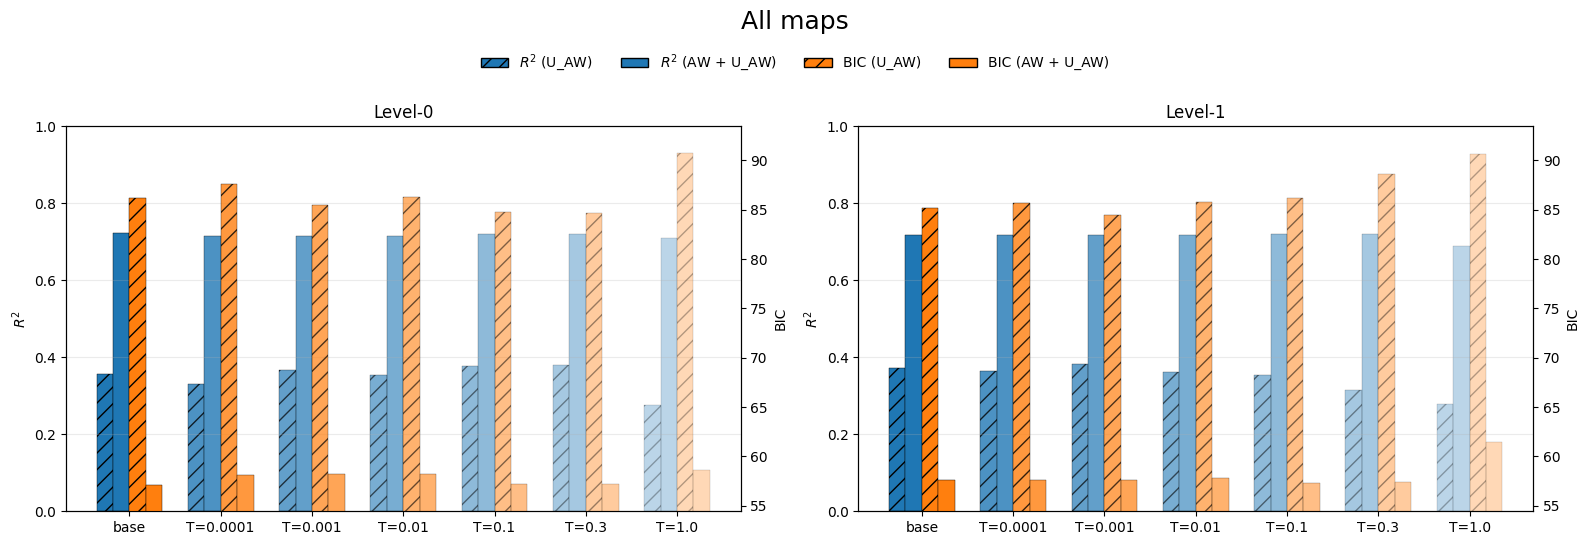

,temp_key,subset,BIC_full_L0,R2_full_L0,BIC_full_L1,R2_full_L1,delta_BIC_L1_minus_L0,delta_R2_L1_minus_L0,winner_by_BIC
0,base,all,57.121534,0.721737,57.637911,0.718028,0.516377,-0.003709,tie
1,0.0001,all,58.063321,0.714936,57.609916,0.718231,-0.453405,0.003295,tie
2,0.001,all,58.187069,0.714030,57.568778,0.718528,-0.618291,0.004498,tie
3,0.01,all,58.177773,0.714098,57.788811,0.716935,-0.388962,0.002837,tie
4,0.1,all,57.184922,0.721285,57.289410,0.720537,0.104488,-0.000748,tie
5,0.3,all,57.154670,0.721501,57.378543,0.719897,0.223873,-0.001603,tie
6,1.0,all,58.617023,0.710860,61.442072,0.689138,2.825049,-0.021722,level-0


In [152]:
subset="all"

df = res_all [res_all [ "subset"] == subset ]
fig, axes = plot_r2_bic_bars_two_panel(df[df["run_type"] != "kwon2023"], base_temperature=0.0001, 
                                       savepath="figures/effect_T_on_fit.png", 
                                       title="All maps")
plt.show()
compare_level1_vs_level0_bic(res_all, subset=subset)

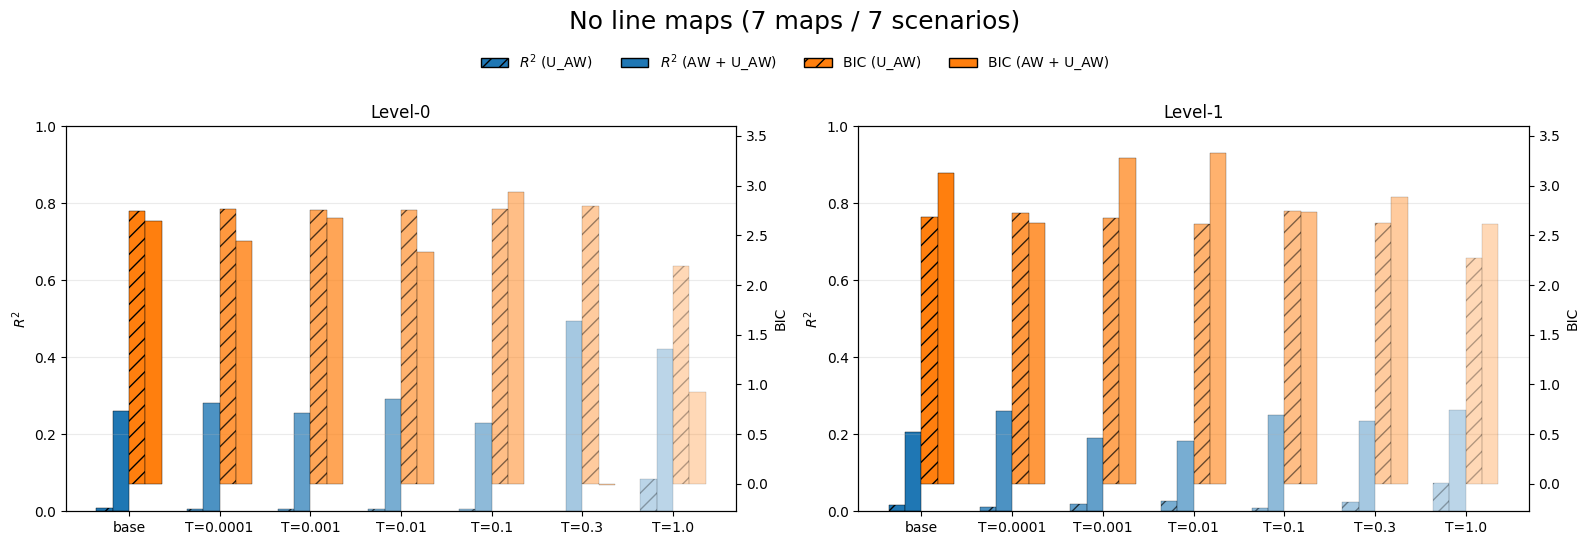

,temp_key,subset,BIC_full_L0,R2_full_L0,BIC_full_L1,R2_full_L1,delta_BIC_L1_minus_L0,delta_R2_L1_minus_L0,winner_by_BIC
0,base,no,2.648603,0.259330,3.129919,0.206611,0.481315,-0.052720,tie
1,0.0001,no,2.441454,0.280928,2.626245,0.261692,0.184791,-0.019235,tie
2,0.001,no,2.676511,0.256372,3.274925,0.190004,0.598414,-0.066368,tie
3,0.01,no,2.329590,0.292327,3.329277,0.183690,0.999687,-0.108637,tie
4,0.1,no,2.931980,0.228731,2.735081,0.250123,-0.196898,0.021392,tie
5,0.3,no,-0.009237,0.493328,2.880473,0.234385,2.889710,-0.258943,level-0
6,1.0,no,0.920946,0.421322,2.613864,0.262997,1.692918,-0.158325,tie


In [156]:
subset="no"

df = res_all [res_all [ "subset"] == subset ]
#display(df)
fig, axes = plot_r2_bic_bars_two_panel(df[df["run_type"] != "kwon2023"], base_temperature=0.0001, 
                                       savepath="figures/effect_T_on_fit_no_maps.png", 
                                       title="No line maps (7 maps / 7 scenarios)")
plt.show()
compare_level1_vs_level0_bic(res_all, subset=subset)

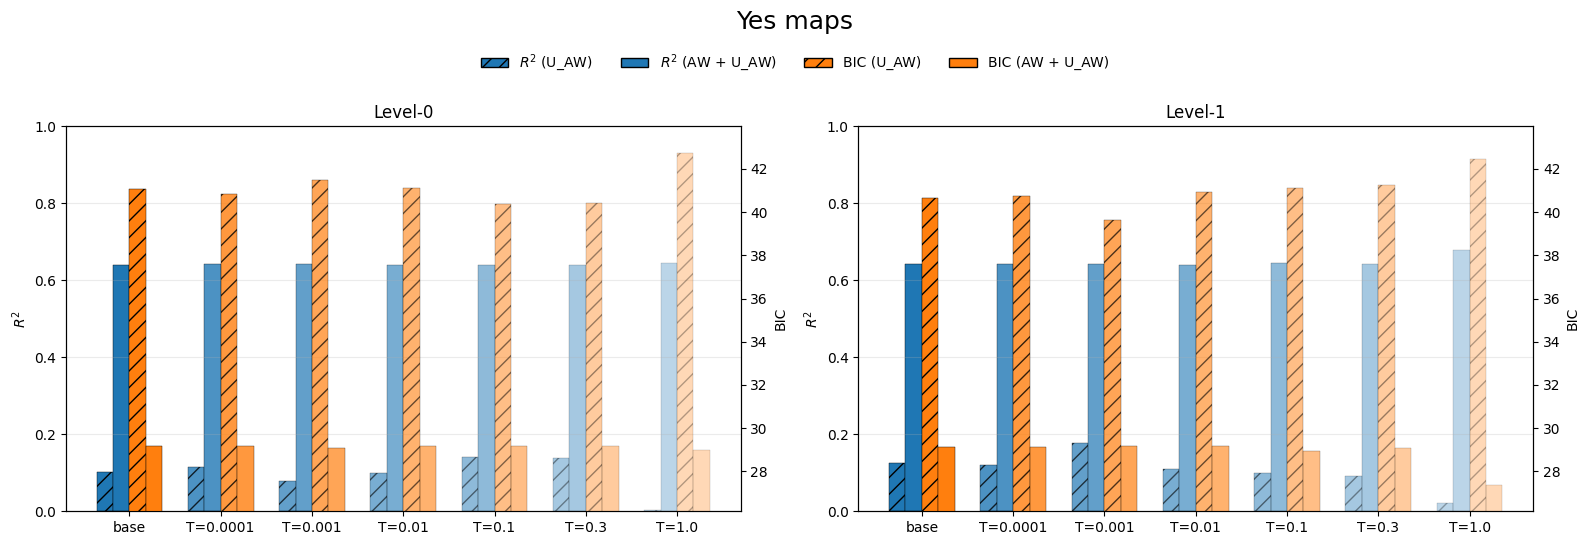

,temp_key,subset,BIC_full_L0,R2_full_L0,BIC_full_L1,R2_full_L1,delta_BIC_L1_minus_L0,delta_R2_L1_minus_L0,winner_by_BIC
0,base,yes,29.194715,0.640703,29.149356,0.641720,-0.045359,0.001017,tie
1,0.0001,yes,29.165042,0.641369,29.125374,0.642257,-0.039668,0.000888,tie
2,0.001,yes,29.067254,0.643554,29.160126,0.641479,0.092872,-0.002075,tie
3,0.01,yes,29.182658,0.640974,29.190319,0.640802,0.007661,-0.000172,tie
4,0.1,yes,29.193209,0.640737,28.959917,0.645937,-0.233292,0.005200,tie
5,0.3,yes,29.186317,0.640892,29.099095,0.642844,-0.087222,0.001952,tie
6,1.0,yes,28.972044,0.645669,27.381518,0.679198,-1.590526,0.033529,tie


In [115]:
subset="yes"

df = res_all [res_all [ "subset"] == subset ]
fig, axes = plot_r2_bic_bars_two_panel(df[df["run_type"] != "kwon2023"], base_temperature=0.0001, savepath=None, 
                                       title="Yes maps")
plt.show()
compare_level1_vs_level0_bic(res_all, subset=subset)

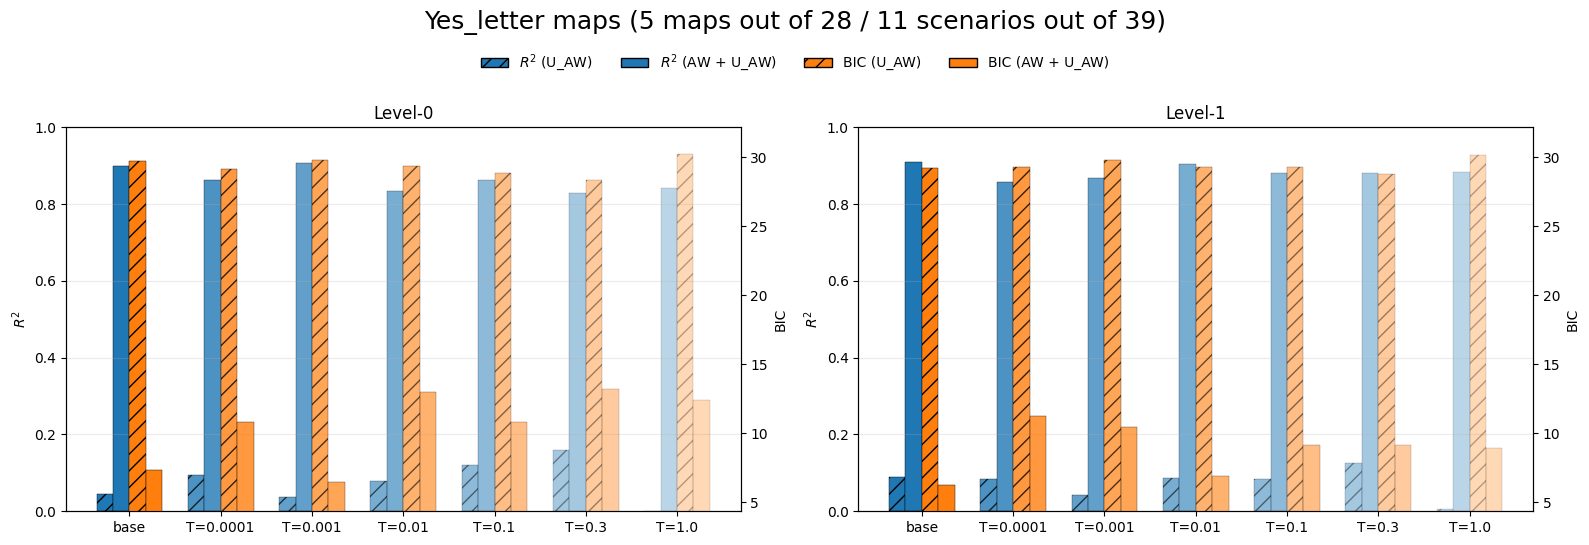

,temp_key,subset,BIC_full_L0,R2_full_L0,BIC_full_L1,R2_full_L1,delta_BIC_L1_minus_L0,delta_R2_L1_minus_L0,winner_by_BIC
0,base,yes_letter,7.325081,0.899979,6.252667,0.909270,-1.072414,0.009291,tie
1,0.0001,yes_letter,10.832951,0.862410,11.237018,0.857262,0.404067,-0.005148,tie
2,0.001,yes_letter,6.449866,0.907629,10.408202,0.867622,3.958336,-0.040007,level-0
3,0.01,yes_letter,12.958450,0.833082,6.876735,0.903974,-6.081715,0.070892,level-1
4,0.1,yes_letter,10.840007,0.862322,9.127355,0.882172,-1.712652,0.019850,tie
5,0.3,yes_letter,13.203386,0.829323,9.127502,0.882171,-4.075884,0.052847,level-1
6,1.0,yes_letter,12.436727,0.840814,8.917278,0.884401,-3.519448,0.043588,level-1


In [160]:
subset="yes_letter"

df = res_all [res_all [ "subset"] == subset ]
fig, axes = plot_r2_bic_bars_two_panel(df[df["run_type"] != "kwon2023"], base_temperature=0.0001, 
                                       savepath="figures/effect_T_on_fit_yes_letter.png", 
                                       title="Yes_letter maps (5 maps out of 28 / 11 scenarios out of 39)")
plt.show()
compare_level1_vs_level0_bic(res_all, subset=subset)

In [159]:
df

,run_type,base_run,temperature,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
60,kwon2023,kwon2023,NaN,yes_number,5,0.448357,8.385061,0.005065,11.333940,0.559088,8.874224,0.110731,0.489163
61,level-0,level-0,NaN,yes_number,5,0.448357,8.385061,0.163792,10.464943,0.611405,8.242679,0.163048,-0.142382
62,level-0_noise-0.0001,level-0,0.0001,yes_number,5,0.448357,8.385061,0.449064,8.378646,0.790280,5.158849,0.341924,-3.226213
63,level-0_noise-0.001,level-0,0.0010,yes_number,5,0.448357,8.385061,0.270709,9.780922,0.730986,6.403803,0.282629,-1.981258
64,level-0_noise-0.01,level-0,0.0100,yes_number,5,0.448357,8.385061,0.157286,10.503696,0.572569,8.718954,0.124212,0.333893
65,level-0_noise-0.1,level-0,0.1000,yes_number,5,0.448357,8.385061,0.110110,10.776043,0.614000,8.209182,0.165643,-0.175879
66,level-0_noise-0.3,level-0,0.3000,yes_number,5,0.448357,8.385061,0.385812,8.922063,0.705833,6.850724,0.257477,-1.534337
67,level-0_noise-1.0,level-0,1.0000,yes_number,5,0.448357,8.385061,0.555407,7.306354,0.711780,6.748618,0.263423,-1.636443
68,level-1,level-1,NaN,yes_number,5,0.448357,8.385061,0.150512,10.543725,0.603671,8.341218,0.155314,-0.043843
69,level-1_noise-0.0001,level-1,0.0001,yes_number,5,0.448357,8.385061,0.128420,10.672094,0.540315,9.082700,0.091958,0.697639


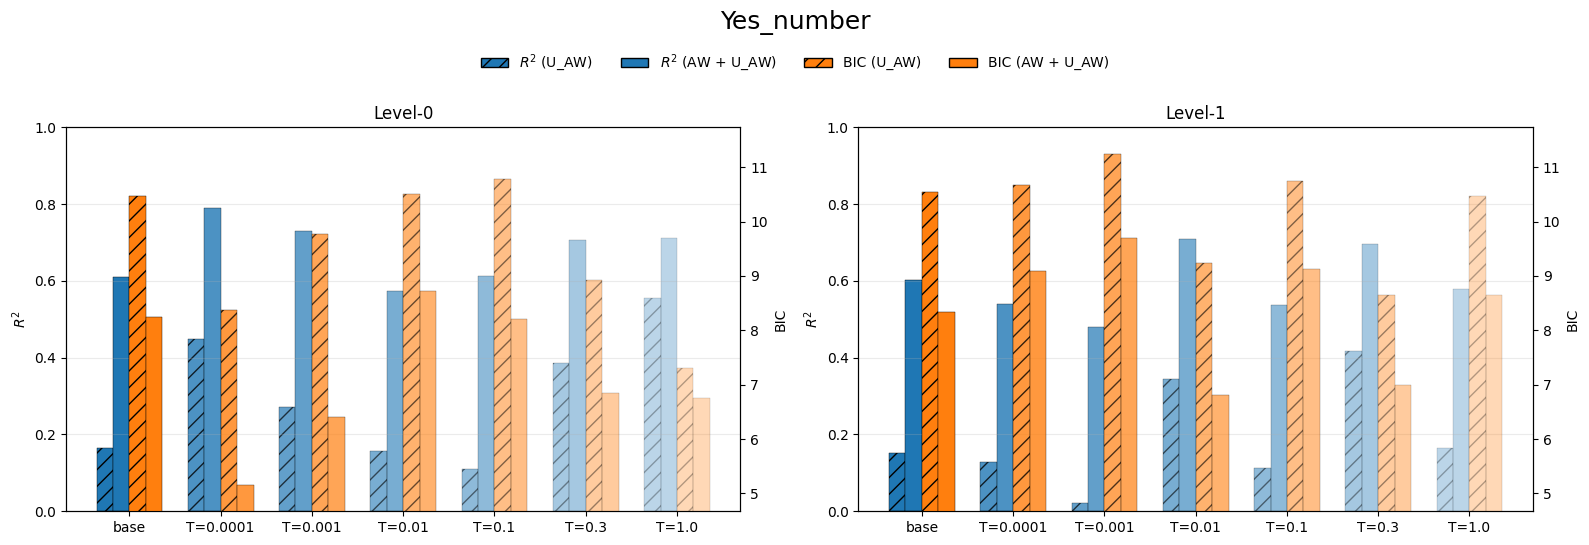

,temp_key,subset,BIC_full_L0,R2_full_L0,BIC_full_L1,R2_full_L1,delta_BIC_L1_minus_L0,delta_R2_L1_minus_L0,winner_by_BIC
0,base,yes_number,8.242679,0.611405,8.341218,0.603671,0.098539,-0.007734,tie
1,0.0001,yes_number,5.158849,0.790280,9.082700,0.540315,3.923851,-0.249965,level-0
2,0.001,yes_number,6.403803,0.730986,9.699999,0.479910,3.296196,-0.251076,level-0
3,0.01,yes_number,8.718954,0.572569,6.811094,0.708156,-1.907860,0.135586,tie
4,0.1,yes_number,8.209182,0.614000,9.121674,0.536718,0.912492,-0.077282,tie
5,0.3,yes_number,6.850724,0.705833,6.999871,0.696926,0.149148,-0.008907,tie
6,1.0,yes_number,6.748618,0.711780,8.657068,0.577827,1.908450,-0.133953,tie


In [158]:
subset="yes_number"

df = res_all [res_all [ "subset"] == subset ]
fig, axes = plot_r2_bic_bars_two_panel(df[df["run_type"] != "kwon2023"], base_temperature=0.0001, 
                                       savepath="figures/effect_T_on_fit_yes_number.png", 
                                       title="Yes_number")
plt.show()
compare_level1_vs_level0_bic(res_all, subset=subset)

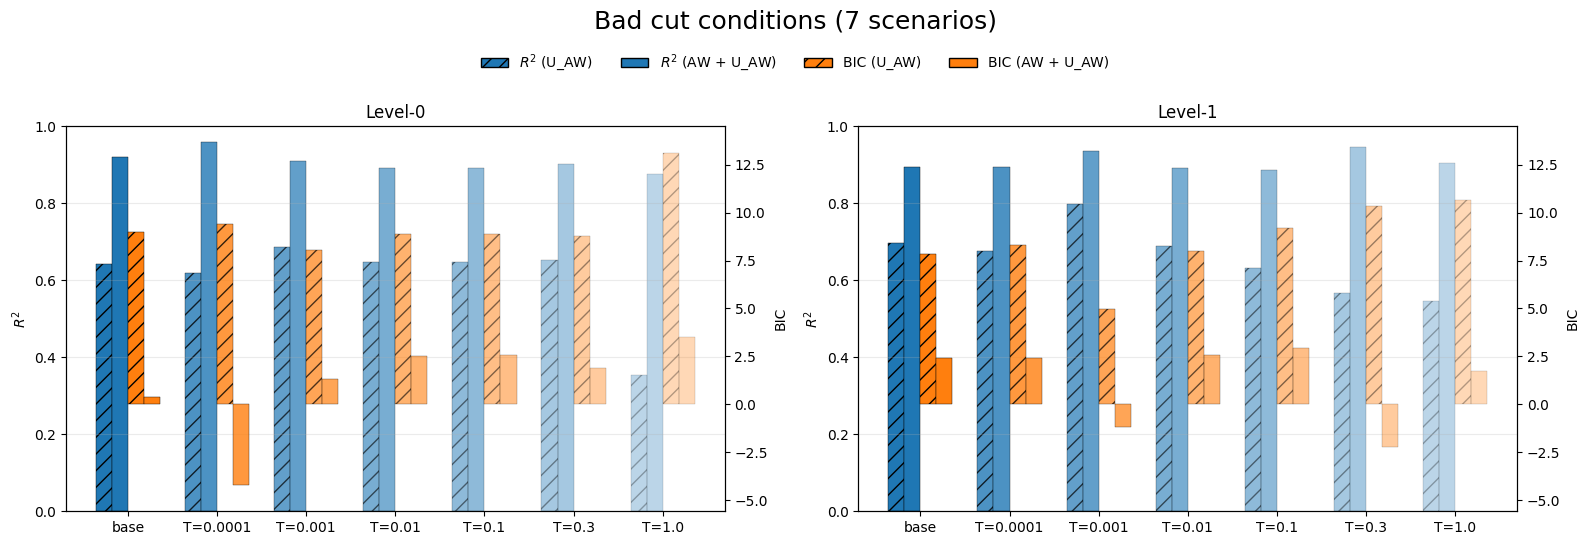

,temp_key,subset,BIC_full_L0,R2_full_L0,BIC_full_L1,R2_full_L1,delta_BIC_L1_minus_L0,delta_R2_L1_minus_L0,winner_by_BIC
0,base,bad_cut,0.390258,0.920658,2.415982,0.894030,2.025725,-0.026628,level-0
1,0.0001,bad_cut,-4.190667,0.958762,2.427852,0.893850,6.618519,-0.064912,level-0
2,0.001,bad_cut,1.310610,0.909509,-1.192863,0.936718,-2.503474,0.027208,level-1
3,0.01,bad_cut,2.504034,0.892688,2.570521,0.891664,0.066487,-0.001024,tie
4,0.1,bad_cut,2.584424,0.891449,2.940066,0.885791,0.355643,-0.005658,tie
5,0.3,bad_cut,1.916721,0.901325,-2.222064,0.945370,-4.138785,0.044045,level-1
6,1.0,bad_cut,3.532513,0.875704,1.761140,0.903494,-1.771373,0.027789,tie


In [146]:
subset="bad_cut"

df = res_all [res_all [ "subset"] == subset ]
fig, axes = plot_r2_bic_bars_two_panel(df[df["run_type"] != "kwon2023"], base_temperature=0.0001, 
                                       savepath="figures/effect_T_on_fit_bad_cut.png", 
                                       title="Bad cut conditions (7 scenarios)")
plt.show()
compare_level1_vs_level0_bic(res_all, subset=subset)

In [149]:
df

,run_type,base_run,temperature,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
165,kwon2023,kwon2023,NaN,bad_cut,7,0.714536,7.40679,0.735319,6.877635,0.879622,3.308338,0.165086,-4.098453
166,level-0,level-0,NaN,bad_cut,7,0.714536,7.40679,0.642771,8.976603,0.920658,0.390258,0.206122,-7.016533
167,level-0_noise-0.0001,level-0,0.0001,bad_cut,7,0.714536,7.40679,0.619716,9.414395,0.958762,-4.190667,0.244227,-11.597457
168,level-0_noise-0.001,level-0,0.0010,bad_cut,7,0.714536,7.40679,0.687091,8.049355,0.909509,1.310610,0.194974,-6.096180
169,level-0_noise-0.01,level-0,0.0100,bad_cut,7,0.714536,7.40679,0.646295,8.907210,0.892688,2.504034,0.178153,-4.902756
170,level-0_noise-0.1,level-0,0.1000,bad_cut,7,0.714536,7.40679,0.648382,8.865795,0.891449,2.584424,0.176913,-4.822367
171,level-0_noise-0.3,level-0,0.3000,bad_cut,7,0.714536,7.40679,0.652291,8.787523,0.901325,1.916721,0.186789,-5.490070
172,level-0_noise-1.0,level-0,1.0000,bad_cut,7,0.714536,7.40679,0.355069,13.111971,0.875704,3.532513,0.161169,-3.874277
173,level-1,level-1,NaN,bad_cut,7,0.714536,7.40679,0.695773,7.852388,0.894030,2.415982,0.179494,-4.990808
174,level-1_noise-0.0001,level-1,0.0001,bad_cut,7,0.714536,7.40679,0.676256,8.287645,0.893850,2.427852,0.179314,-4.978938


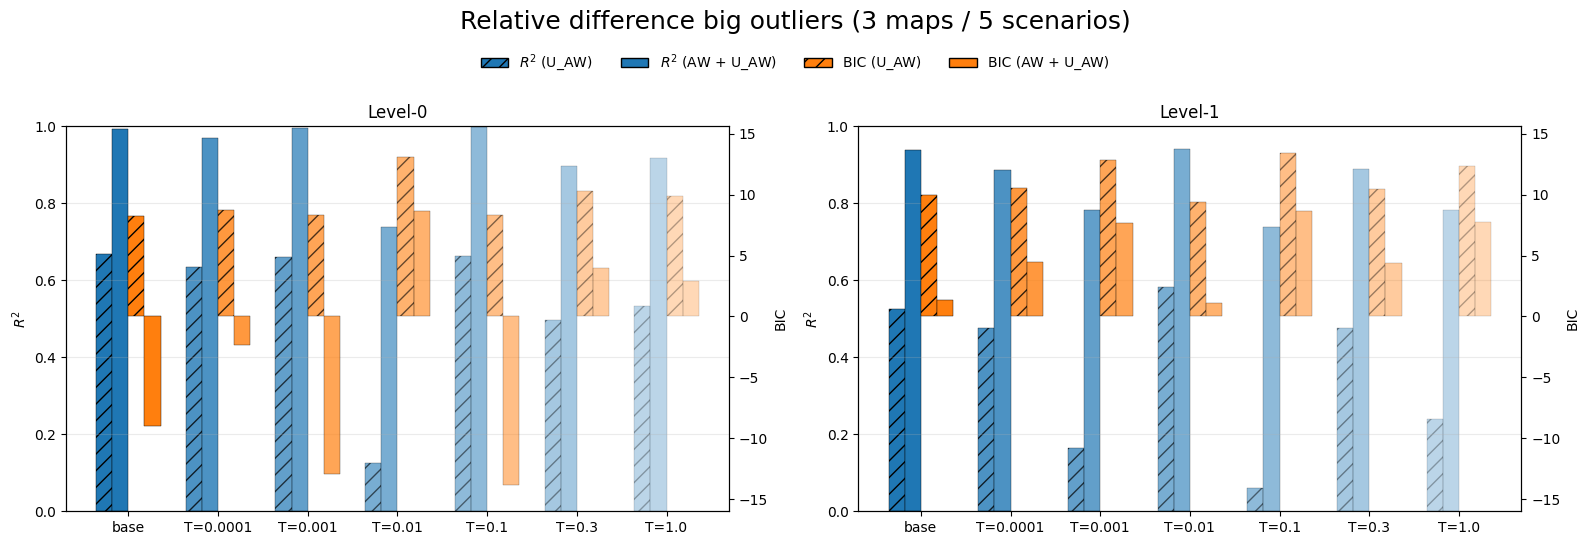

,temp_key,subset,BIC_full_L0,R2_full_L0,BIC_full_L1,R2_full_L1,delta_BIC_L1_minus_L0,delta_R2_L1_minus_L0,winner_by_BIC
0,base,maps_rel1,-8.975626,0.992293,1.339451,0.939348,10.315077,-0.052945,level-0
1,0.0001,maps_rel1,-2.334458,0.970911,4.440133,0.887237,6.774592,-0.083674,level-0
2,0.001,maps_rel1,-12.966271,0.996531,7.700444,0.783552,20.666715,-0.212978,level-0
3,0.01,maps_rel1,8.644501,0.738572,1.083977,0.942369,-7.560525,0.203798,level-1
4,0.1,maps_rel1,-13.815276,0.997072,8.652994,0.738127,22.468269,-0.258945,level-0
5,0.3,maps_rel1,3.936329,0.898046,4.409453,0.887927,0.473124,-0.010119,tie
6,1.0,maps_rel1,2.930093,0.916631,7.738662,0.781892,4.808569,-0.134739,level-0


In [145]:
subset="maps_rel1"

df = res_all [res_all [ "subset"] == subset ]
fig, axes = plot_r2_bic_bars_two_panel(df[df["run_type"] != "kwon2023"], base_temperature=0.0001, 
                                       savepath="figures/effect_T_on_fit_relative_diff_big_outliers.png", 
                                       title="Relative difference big outliers (3 maps / 5 scenarios)")
plt.show()
compare_level1_vs_level0_bic(res_all, subset=subset)

In [144]:
df

,run_type,base_run,temperature,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
240,kwon2023,kwon2023,NaN,maps_rel1,5,0.70332,7.667539,0.598065,9.185714,0.950595,0.313975,0.247275,-7.353565
241,level-0,level-0,NaN,maps_rel1,5,0.70332,7.667539,0.667567,8.236450,0.992293,-8.975626,0.288973,-16.643165
242,level-0_noise-0.0001,level-0,0.0001,maps_rel1,5,0.70332,7.667539,0.633798,8.720189,0.970911,-2.334458,0.267591,-10.001998
243,level-0_noise-0.001,level-0,0.0010,maps_rel1,5,0.70332,7.667539,0.661350,8.329091,0.996531,-12.966271,0.293211,-20.633811
244,level-0_noise-0.01,level-0,0.0100,maps_rel1,5,0.70332,7.667539,0.124587,13.077739,0.738572,8.644501,0.035252,0.976962
245,level-0_noise-0.1,level-0,0.1000,maps_rel1,5,0.70332,7.667539,0.662942,8.305538,0.997072,-13.815276,0.293753,-21.482815
246,level-0_noise-0.3,level-0,0.3000,maps_rel1,5,0.70332,7.667539,0.497561,10.301628,0.898046,3.936329,0.194726,-3.731210
247,level-0_noise-1.0,level-0,1.0000,maps_rel1,5,0.70332,7.667539,0.534255,9.922458,0.916631,2.930093,0.213311,-4.737446
248,level-1,level-1,NaN,maps_rel1,5,0.70332,7.667539,0.526161,10.008597,0.939348,1.339451,0.236029,-6.328088
249,level-1_noise-0.0001,level-1,0.0001,maps_rel1,5,0.70332,7.667539,0.475672,10.514846,0.887237,4.440133,0.183918,-3.227406


In [117]:
subset_list = [
    "all",
    "yes", "no", "maybe",
    "yes_number", "yes_letter", "no_number", "no_letter",
    "new_maybe", "esque",
    "normal_cut", "bad_cut", "badder_cut", "worse_cut",
    "maps_z", "maps_d", "maps_rel1", "maps_rel2", "maps_rel3", "maps_sd",
]


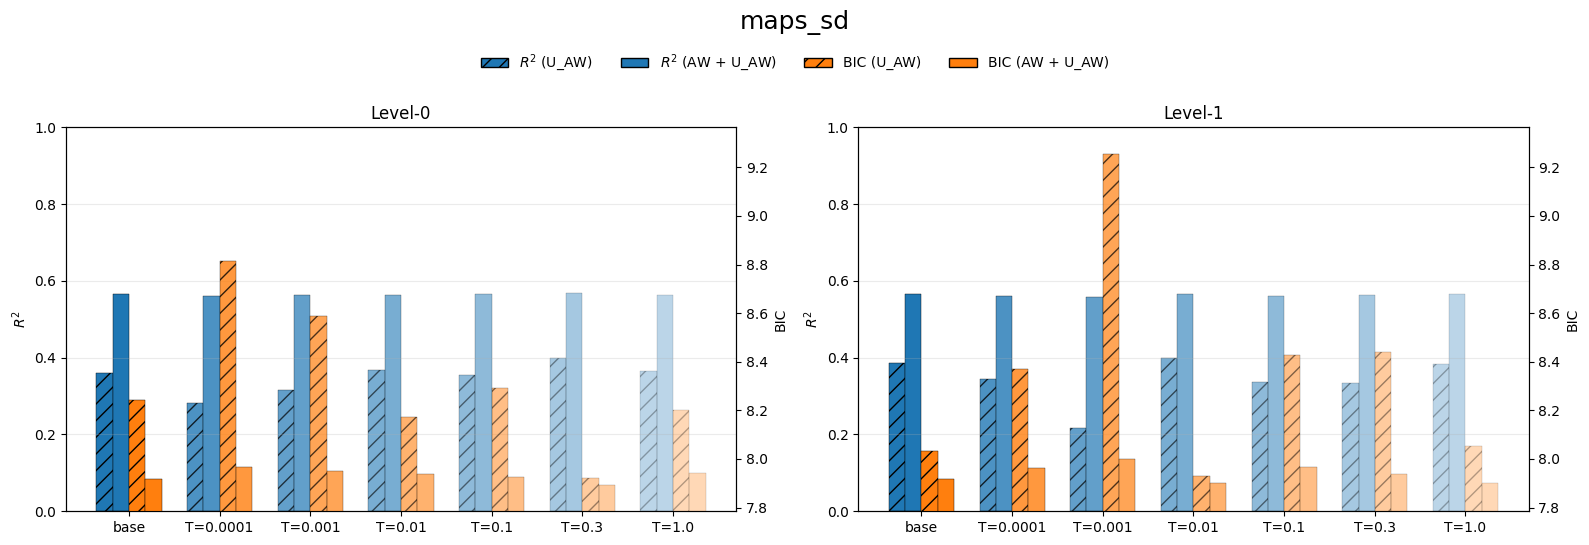

,temp_key,subset,BIC_full_L0,R2_full_L0,BIC_full_L1,R2_full_L1,delta_BIC_L1_minus_L0,delta_R2_L1_minus_L0,winner_by_BIC
0,base,maps_sd,7.919467,0.565499,7.918106,0.565617,-0.001361,0.000118,tie
1,0.0001,maps_sd,7.968681,0.561201,7.961998,0.561787,-0.006683,0.000586,tie
2,0.001,maps_sd,7.949771,0.562857,8.001730,0.558291,0.051958,-0.004566,tie
3,0.01,maps_sd,7.938237,0.563864,7.899789,0.567205,-0.038448,0.003341,tie
4,0.1,maps_sd,7.923850,0.565118,7.968077,0.561254,0.044226,-0.003864,tie
5,0.3,maps_sd,7.893614,0.567740,7.936973,0.563975,0.043358,-0.003765,tie
6,1.0,maps_sd,7.941443,0.563585,7.902178,0.566998,-0.039264,0.003414,tie


In [139]:
subset="maps_sd"

df = res_all [res_all [ "subset"] == subset ]
fig, axes = plot_r2_bic_bars_two_panel(df[df["run_type"] != "kwon2023"], base_temperature=0.0001, 
                                       savepath=None,
                                       title=subset)
plt.show()
compare_level1_vs_level0_bic(res_all, subset=subset)

In [162]:
## Dec 17, big grpqh per map? --- what question is this answering???


import numpy as np
import pandas as pd
import statsmodels.api as sm

def run_str(base_run: str, noise):
    # noise can be "base" or a float
    return base_run if noise == "base" else f"{base_run}_noise-{noise}"

def per_map_delta_se(design_df, run_type, m_AW_global=None):
    """
    Returns a df with one row per scenario (map/condition) containing:
      delta_se = SE_AW - SE_full
    If m_AW_global is provided, uses that same AW-only model for everyone.
    Otherwise fits AW-only per run_df (less comparable across run types).
    """
    df_rt = design_df.copy()

    # pick columns
    map_name = df_rt["map_name"] if "map_name" in df_rt.columns else df_rt["xp_name"]
    condition = df_rt["condition"] if "condition" in df_rt.columns else "NA"

    y = df_rt["rating_mean"]

    X_AW = sm.add_constant(df_rt[["aggregate_welfare"]], has_constant="add")
    if m_AW_global is None:
        m_AW = sm.OLS(y, X_AW).fit()
        y_hat_AW = m_AW.predict(X_AW)
    else:
        y_hat_AW = m_AW_global.predict(X_AW)

    X_full = sm.add_constant(df_rt[["aggregate_welfare", "univ_aggregate_welfare"]], has_constant="add")
    m_full = sm.OLS(y, X_full).fit()
    y_hat_full = m_full.predict(X_full)

    delta_se = (y - y_hat_AW) ** 2 - (y - y_hat_full) ** 2

    return pd.DataFrame({
        "run_type": run_type,
        "xp_name": df_rt["xp_name"],
        "map_name": map_name,
        "condition": condition,
        "delta_se": delta_se,
    })

def per_map_summary_level0_vs_level1_for_noise(design_source, noise, m_AW_global=None):
    """
    design_source: dict[run_type] -> design_df
      (use design_by_run OR design_by_subset[subset_name])
    """
    rt0 = run_str("level-0", noise)
    rt1 = run_str("level-1", noise)

    if rt0 not in design_source or rt1 not in design_source:
        return None  # missing run(s)

    rows = []
    rows.append(per_map_delta_se(design_source[rt0], rt0, m_AW_global=m_AW_global))
    rows.append(per_map_delta_se(design_source[rt1], rt1, m_AW_global=m_AW_global))
    per_map_long = pd.concat(rows, ignore_index=True)

    group_cols = ["xp_name", "map_name", "condition"]

    summary = (
        per_map_long
        .groupby(group_cols, as_index=False)
        .agg(mean_delta_se=("delta_se", "mean"))
    )

    wide = (
        per_map_long
        .pivot_table(index=group_cols, columns="run_type", values="delta_se", aggfunc="mean")
        .reset_index()
    )
    wide.columns.name = None

    out = summary.merge(wide, on=group_cols, how="left")
    out = out.sort_values("mean_delta_se", ascending=False)
    return out

import matplotlib.pyplot as plt

def plot_per_map_improvement_for_noise(per_map_summary, noise, savepath=None):
    if per_map_summary is None or per_map_summary.empty:
        return

    # identify the two columns (run types) present
    rt_cols = [c for c in per_map_summary.columns if c.startswith("level-0") or c.startswith("level-1")]

    for cond in sorted(per_map_summary["condition"].unique()):
        sub = per_map_summary[per_map_summary["condition"] == cond].reset_index(drop=True)
        if sub.empty:
            continue

        fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(sub))))
        y_pos = np.arange(len(sub))

        ax.barh(y_pos, sub["mean_delta_se"], alpha=0.3, label="mean ΔSE (across runs shown)")

        # scatter for each run type present
        for rt in rt_cols:
            if rt in sub.columns:
                ax.scatter(sub[rt], y_pos, s=25, label=rt)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(sub["map_name"])
        ax.set_xlabel("Improvement in squared error (SE_AW − SE_full)")
        ax.set_title(f"Per-map improvement from U_AW | noise = {noise} | condition = {cond}")

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc="lower right")

        fig.tight_layout()
        if savepath is not None:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()


In [168]:
noise_list = ["base", 0.0001, 0.001, 0.01, 0.1, 0.3, 1.0]

import statsmodels.api as sm

df_ref = design_by_run["level-0"]   # or "kwon2023", or any reference run you want
X_AW = sm.add_constant(df_ref[["aggregate_welfare"]], has_constant="add")
y = df_ref["rating_mean"]
m_AW_global = sm.OLS(y, X_AW).fit()


# choose your source:
# design_source = design_by_run
# OR, if you want a subset:
# design_source = design_by_subset["all"]   # or "yes", "worse_cut", etc.

design_source = design_by_run  # example

#for noise in noise_list:
 #   pm = per_map_summary_level0_vs_level1_for_noise(design_source, noise, m_AW_global=m_AW_global)
  #  plot_per_map_improvement_for_noise(pm, noise)


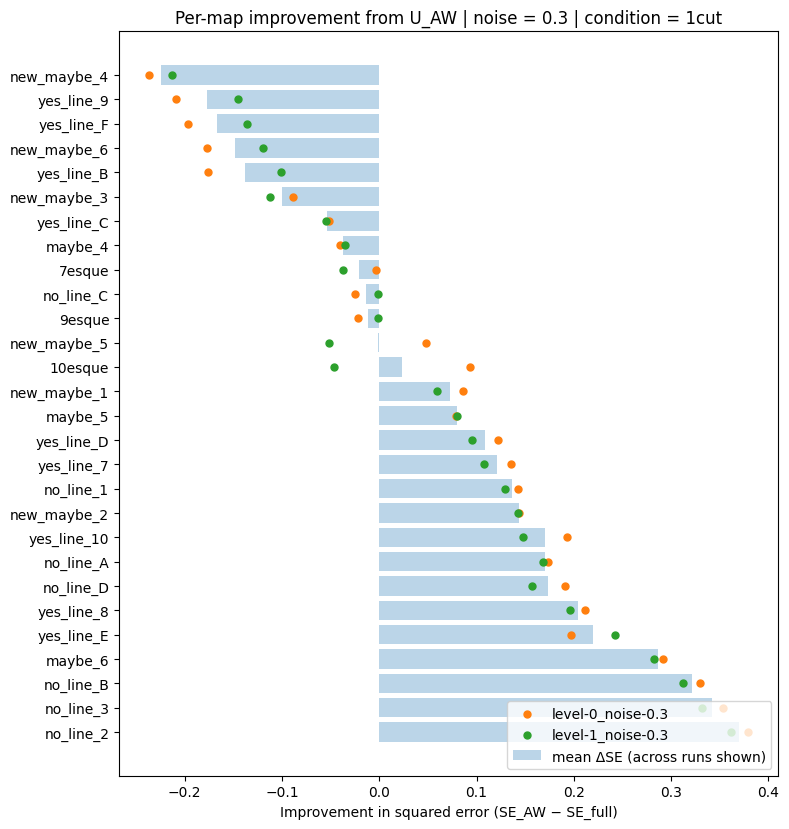

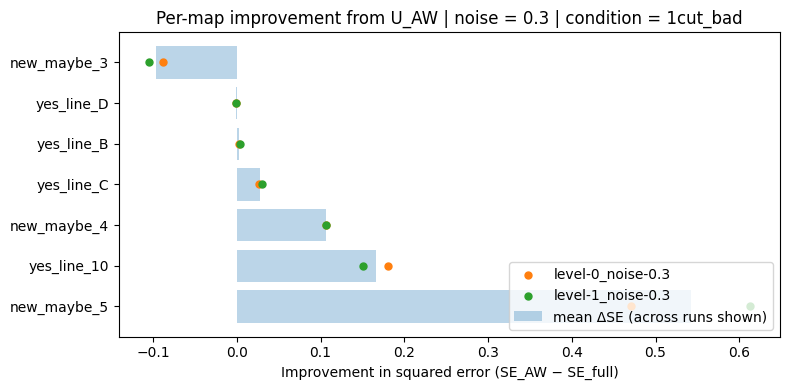

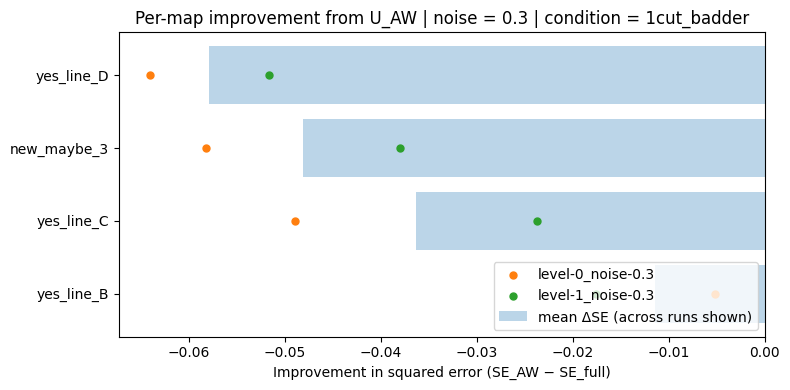

In [169]:
pm = per_map_summary_level0_vs_level1_for_noise(design_source, "0.3", m_AW_global=m_AW_global)
plot_per_map_improvement_for_noise(pm, "0.3")


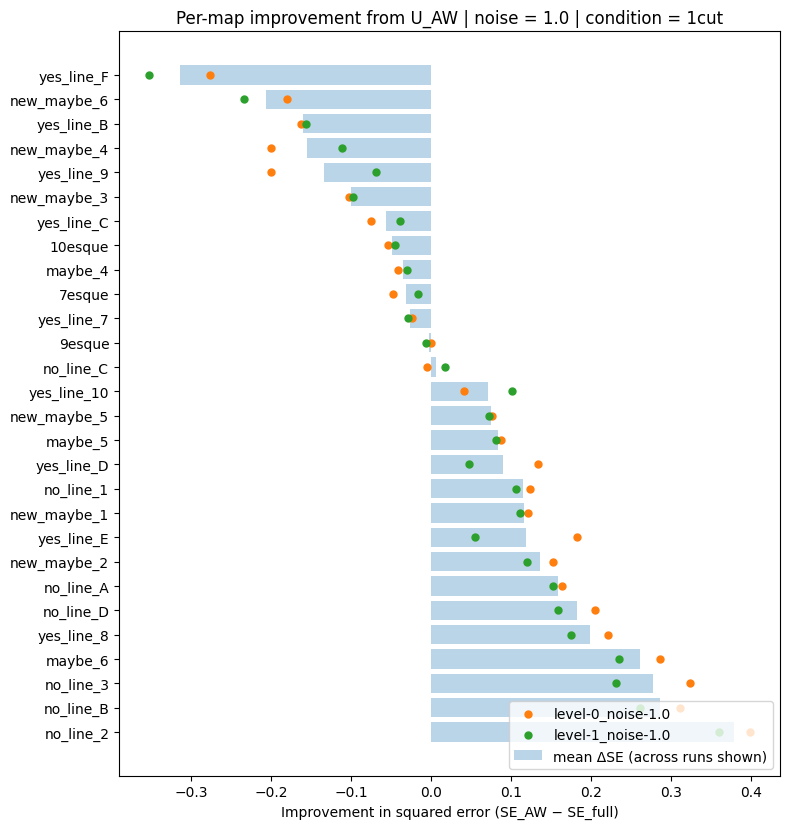

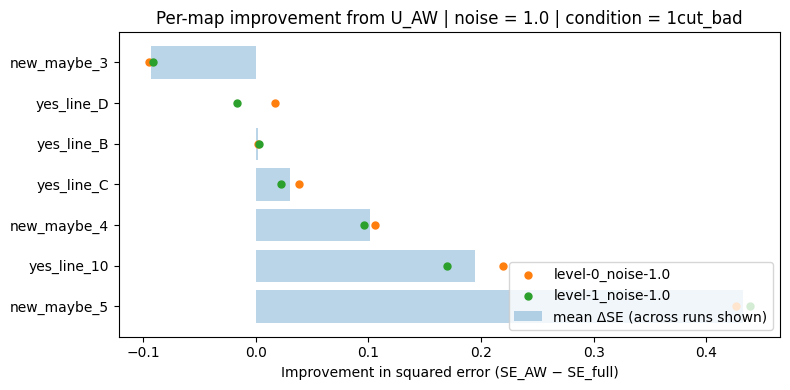

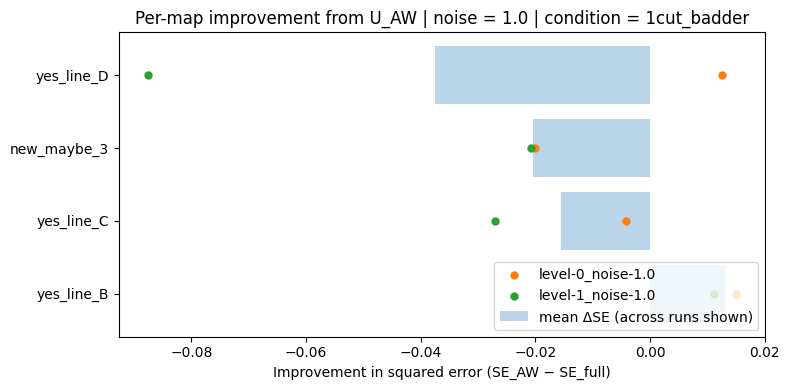

In [170]:
pm = per_map_summary_level0_vs_level1_for_noise(design_source, "1.0", m_AW_global=m_AW_global)
plot_per_map_improvement_for_noise(pm, "1.0")


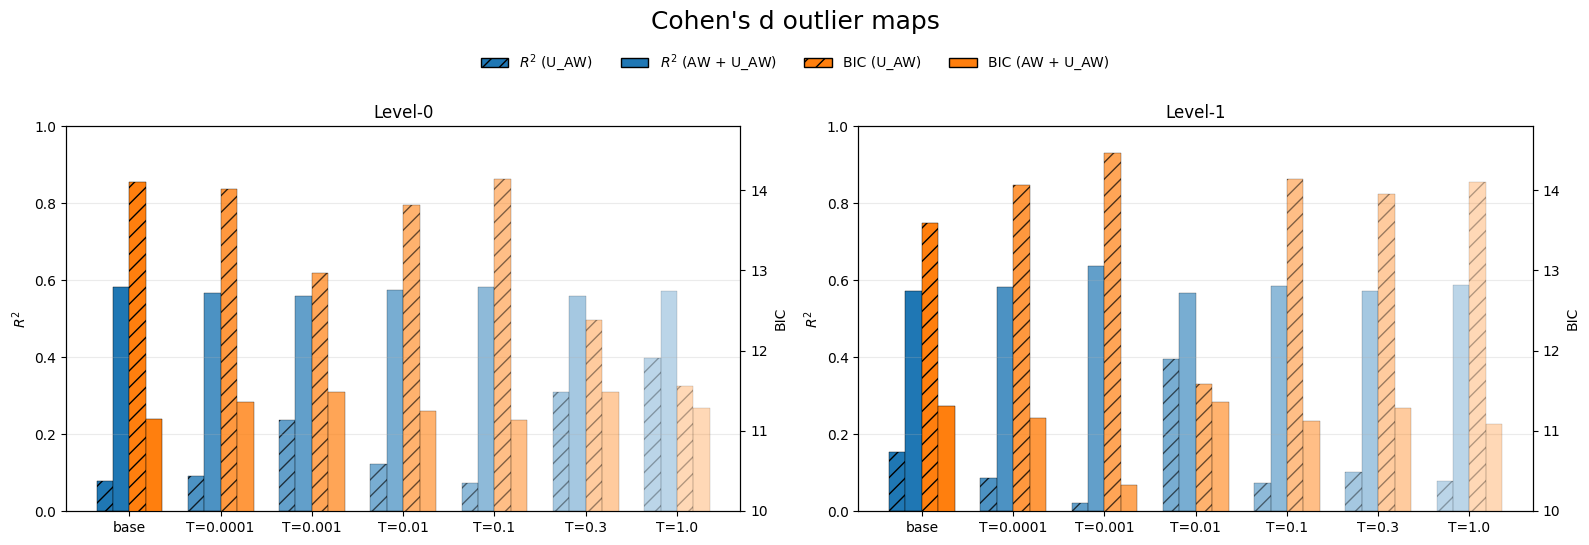

In [87]:
df = res_all [res_all [ "subset"] == "maps_d"]
fig, axes = plot_r2_bic_bars_two_panel(df [ df ["run_type"] != "kwon2023"], base_temperature=0.0001, savepath=None, title="Cohen's d outlier maps")
plt.show()

In [14]:
res_all = compare_run_types_on_subset(design_by_run,   "all")

res_z     = compare_run_types_on_subset(design_maps_z_by_run, "maps_Z")
res_d     = compare_run_types_on_subset(design_maps_d_by_run, "maps_D")# For every run type, retrieve summary per-map universalization metrics,
res_rel1     = compare_run_types_on_subset(design_maps_rel1_by_run, "maps_relative_big")# For every run type, retrieve summary per-map universalization metrics,
res_rel2     = compare_run_types_on_subset(design_maps_rel2_by_run, "maps_relative_normal")# For every run type, retrieve summary per-map universalization metrics,
res_rel3     = compare_run_types_on_subset(design_maps_rel3_by_run, "maps_relative_all")# For every run type, retrieve summary per-map universalization metrics,
res_sd     = compare_run_types_on_subset(design_maps_sd_by_run, "maps_sd")

# and build regression-ready design matrix
RUN_TYPES = ["kwon2023", "level-0", "level-1"]

res_all = pd.concat([res_all, res_z, res_d, res_rel1, res_rel2, res_rel3, res_sd], ignore_index=True)
res_all

### NOT MUCH GOING ON: lvl 0 is better on the very small subset of maps with huge relative diff.

,run_type,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
0,kwon2023,all,39,0.629469,64.626429,0.381760,84.592110,0.714412,58.134865,0.084943,-6.491564
1,level-0,all,39,0.629469,64.626429,0.356533,86.151866,0.721737,57.121534,0.092268,-7.504895
2,level-1,all,39,0.629469,64.626429,0.372141,85.194239,0.718028,57.637911,0.088559,-6.988519
3,kwon2023,maps_Z,13,0.828433,12.728846,0.599316,23.755433,0.828541,15.285592,0.000108,2.556745
4,level-0,maps_Z,13,0.828433,12.728846,0.601993,23.668301,0.828539,15.285770,0.000106,2.556923
5,level-1,maps_Z,13,0.828433,12.728846,0.579129,24.394442,0.828681,15.274960,0.000248,2.546114
6,kwon2023,maps_D,6,0.558391,9.693833,0.057782,14.240699,0.636111,10.324137,0.077720,0.630304
7,level-0,maps_D,6,0.558391,9.693833,0.078641,14.106381,0.582813,11.144244,0.024422,1.450411
8,level-1,maps_D,6,0.558391,9.693833,0.154191,13.593039,0.571048,11.311105,0.012658,1.617272
9,kwon2023,maps_relative_big,5,0.703320,7.667539,0.598065,9.185714,0.950595,0.313975,0.247275,-7.353565


In [ ]:
fig, axes = plot_r2_bic_bars_two_panel(df, base_temperature=0.0001, savepath=None)
plt.show()


In [12]:
# --- Draft: helper to compare run types on subset --- #
def compare_run_types_on_subset(subset_dict_by_run, subset_label):
    rows = []
    for rt in RUN_TYPES:
        design_S = subset_dict_by_run[rt]

        # AW-only baseline
        row_AW, m_AW = fit_ols(
            design_df=design_S,
            predictors=["aggregate_welfare"],
            dv="rating_mean",
            run_type=f"{rt}_{subset_label}_AW",
        )
        R2_AW = row_AW["R2"]
        BIC_AW = row_AW["BIC"]

        # Simple U_AW-only
        row_univ, m_univ = fit_ols(
            design_df=design_S,
            predictors=["univ_aggregate_welfare"],
            dv="rating_mean",
            run_type=f"{rt}_{subset_label}_U_AW",
        )
        R2_univ = row_univ["R2"]
        BIC_univ = row_univ["BIC"]

        if len(design_S) > 3: 
            row_full, m_full = fit_ols(
                design_df=design_S,
                predictors=["aggregate_welfare", "univ_aggregate_welfare"],
                dv="rating_mean",
                run_type=f"{rt}_{subset_label}_AW+U_AW",
            )
            R2_full=row_full["R2"]
            BIC_full=row_full["BIC"]
            delta_R2= (R2_full - R2_AW).round(6)
            delta_BIC= (BIC_full - BIC_AW).round(6)
        else:
            R2_full = np.nan
            BIC_full = np.nan
            delta_R2= np.nan
            delta_BIC = np.nan
            
        rows.append({
            "run_type": rt,
            "subset": subset_label,
            "n": len(design_S),
            "R2_AW": R2_AW,
            "BIC_AW": BIC_AW,
            "R2_univ": R2_univ,
            "BIC_univ": BIC_univ,
            "R2_full": R2_full,
            "BIC_full": BIC_full,
            "delta_R2_full_vs_AW": delta_R2,
            "delta_BIC_full_vs_AW": delta_BIC,
        })

    return pd.DataFrame(rows)

In [120]:
res_all = compare_run_types_on_subset(design_by_run,   "all")

res_yes   = compare_run_types_on_subset(design_yes_by_run,   "yes")
res_no    = compare_run_types_on_subset(design_no_by_run,    "no")
res_maybe = compare_run_types_on_subset(design_maybe_by_run, "maybe")
res_bad   = compare_run_types_on_subset(design_worse_cut_by_run, "bad+badder")
res_z     = compare_run_types_on_subset(design_maps_z_by_run, "maps_Z")
res_d     = compare_run_types_on_subset(design_maps_d_by_run, "maps_D")# For every run type, retrieve summary per-map universalization metrics,
res_rel     = compare_run_types_on_subset(design_maps_rel_by_run, "maps_relative")# For every run type, retrieve summary per-map universalization metrics,

# and build regression-ready design matrix
RUN_TYPES = ["kwon2023", "level-0", "level-1"]

res_all = pd.concat([res_all, res_yes, res_no, res_maybe, res_bad, res_z, res_d, res_rel], ignore_index=True)
res_all

,run_type,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
0,kwon2023,all,39,0.629469,64.626429,0.381760,84.592110,0.714412,58.134865,0.084943,-6.491564
1,level-0,all,39,0.629469,64.626429,0.356533,86.151866,0.721737,57.121534,0.092268,-7.504895
2,level-1,all,39,0.629469,64.626429,0.372141,85.194239,0.718028,57.637911,0.088559,-6.988519
3,kwon2023,yes,16,0.640703,26.422127,0.116836,40.811905,0.642498,29.114570,0.001795,2.692443
4,level-0,yes,16,0.640703,26.422127,0.102405,41.071241,0.640703,29.194715,0.000000,2.772588
5,level-1,yes,16,0.640703,26.422127,0.125084,40.661777,0.641720,29.149356,0.001017,2.727229
6,kwon2023,no,7,0.120539,1.904976,0.003350,2.780611,0.332760,1.917768,0.212221,0.012792
7,level-0,no,7,0.120539,1.904976,0.008193,2.746509,0.259330,2.648603,0.138792,0.743627
8,level-1,no,7,0.120539,1.904976,0.017314,2.681835,0.206611,3.129919,0.086072,1.224942
9,kwon2023,maybe,16,0.608680,23.797357,0.186057,35.515183,0.685514,23.072566,0.076834,-0.724791


In [126]:
res_all_map_subtypes = pd.concat([res, res_yes, res_yes_number, res_yes_letter,
                    res_no, res_no_number, res_no_letter,
                     res_maybe, res_maybe_maybe, res_new_maybe, res_esque
                    ], ignore_index=True)
res_all_map_subtypes

,run_type,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
0,kwon2023,all,39,0.629469,64.626429,0.381760,84.592110,0.714412,58.134865,0.084943,-6.491564
1,level-0,all,39,0.629469,64.626429,0.356533,86.151866,0.721737,57.121534,0.092268,-7.504895
2,level-1,all,39,0.629469,64.626429,0.372141,85.194239,0.718028,57.637911,0.088559,-6.988519
3,kwon2023,yes,16,0.640703,26.422127,0.116836,40.811905,0.642498,29.114570,0.001795,2.692443
4,level-0,yes,16,0.640703,26.422127,0.102405,41.071241,0.640703,29.194715,0.000000,2.772588
5,level-1,yes,16,0.640703,26.422127,0.125084,40.661777,0.641720,29.149356,0.001017,2.727229
6,kwon2023,yes_number,5,0.448357,8.385061,0.005065,11.333940,0.559088,8.874224,0.110731,0.489163
7,level-0,yes_number,5,0.448357,8.385061,0.163792,10.464943,0.611405,8.242679,0.163048,-0.142382
8,level-1,yes_number,5,0.448357,8.385061,0.150512,10.543725,0.603671,8.341218,0.155314,-0.043843
9,kwon2023,yes_letter,11,0.708287,16.701468,0.015167,30.085205,0.903315,6.951957,0.195027,-9.749512


In [152]:
res_all_cut = pd.concat([res, res_1cut, res_bad, res_badder, res_worse], ignore_index=True)
res_all_cut

,run_type,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
0,kwon2023,all,39,0.629469,64.626429,0.381760,84.592110,0.714412,58.134865,0.084943,-6.491564
1,level-0,all,39,0.629469,64.626429,0.356533,86.151866,0.721737,57.121534,0.092268,-7.504895
2,level-1,all,39,0.629469,64.626429,0.372141,85.194239,0.718028,57.637911,0.088559,-6.988519
3,kwon2023,1cut,28,0.559019,50.320280,0.385160,59.626384,0.666088,45.864969,0.107069,-4.455312
4,level-0,1cut,28,0.559019,50.320280,0.358450,60.817082,0.663436,46.086476,0.104417,-4.233804
5,level-1,1cut,28,0.559019,50.320280,0.387213,59.532697,0.667645,45.734172,0.108626,-4.586108
6,kwon2023,1cut_bad,7,0.714536,7.406790,0.735319,6.877635,0.879622,3.308338,0.165086,-4.098453
7,level-0,1cut_bad,7,0.714536,7.406790,0.642771,8.976603,0.920658,0.390258,0.206122,-7.016533
8,level-1,1cut_bad,7,0.714536,7.406790,0.695773,7.852388,0.894030,2.415982,0.179494,-4.990808
9,kwon2023,1cut_badder,4,0.307140,-2.695687,0.494287,-3.955122,0.497012,-2.590437,0.189872,0.105250


In [116]:
res = compare_run_types_on_subset(design_by_run,   "all")

res_yes   = compare_run_types_on_subset(design_yes_by_run,   "yes")
res_yes_number    = compare_run_types_on_subset(design_yes_number_by_run,    "yes_number")
res_yes_letter    = compare_run_types_on_subset(design_yes_letter_by_run,    "yes_letter")

res_all = pd.concat([res, res_yes, res_yes_number, res_yes_letter], ignore_index=True)
res_all

,run_type,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
0,kwon2023,all,39,0.629469,64.626429,0.381760,84.592110,0.714412,58.134865,0.084943,-6.491564
1,level-0,all,39,0.629469,64.626429,0.356533,86.151866,0.721737,57.121534,0.092268,-7.504895
2,level-1,all,39,0.629469,64.626429,0.372141,85.194239,0.718028,57.637911,0.088559,-6.988519
3,kwon2023,yes,16,0.640703,26.422127,0.116836,40.811905,0.642498,29.114570,0.001795,2.692443
4,level-0,yes,16,0.640703,26.422127,0.102405,41.071241,0.640703,29.194715,0.000000,2.772588
5,level-1,yes,16,0.640703,26.422127,0.125084,40.661777,0.641720,29.149356,0.001017,2.727229
6,kwon2023,yes_number,5,0.448357,8.385061,0.005065,11.333940,0.559088,8.874224,0.110731,0.489163
7,level-0,yes_number,5,0.448357,8.385061,0.163792,10.464943,0.611405,8.242679,0.163048,-0.142382
8,level-1,yes_number,5,0.448357,8.385061,0.150512,10.543725,0.603671,8.341218,0.155314,-0.043843
9,kwon2023,yes_letter,11,0.708287,16.701468,0.015167,30.085205,0.903315,6.951957,0.195027,-9.749512


In [117]:
res = compare_run_types_on_subset(design_by_run,   "all")

res_no   = compare_run_types_on_subset(design_no_by_run,   "no")
res_no_number    = compare_run_types_on_subset(design_no_number_by_run,    "no_number")
res_no_letter    = compare_run_types_on_subset(design_no_letter_by_run,    "no_letter")

res_all = pd.concat([res, res_no, res_no_number, res_no_letter], ignore_index=True)
res_all

,run_type,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
0,kwon2023,all,39,0.629469,64.626429,0.381760,84.592110,0.714412,58.134865,0.084943,-6.491564
1,level-0,all,39,0.629469,64.626429,0.356533,86.151866,0.721737,57.121534,0.092268,-7.504895
2,level-1,all,39,0.629469,64.626429,0.372141,85.194239,0.718028,57.637911,0.088559,-6.988519
3,kwon2023,no,7,0.120539,1.904976,0.003350,2.780611,0.332760,1.917768,0.212221,0.012792
4,level-0,no,7,0.120539,1.904976,0.008193,2.746509,0.259330,2.648603,0.138792,0.743627
5,level-1,no,7,0.120539,1.904976,0.017314,2.681835,0.206611,3.129919,0.086072,1.224942
6,kwon2023,no_number,3,0.423644,1.051801,0.192807,2.062314,NaN,NaN,NaN,NaN
7,level-0,no_number,3,0.423644,1.051801,0.254667,1.823120,NaN,NaN,NaN,NaN
8,level-1,no_number,3,0.423644,1.051801,0.285728,1.695418,NaN,NaN,NaN,NaN
9,kwon2023,no_letter,4,0.002717,-0.828018,0.008237,-0.850219,0.014586,0.510387,0.011869,1.338405


In [118]:
res = compare_run_types_on_subset(design_by_run,   "all")

res_maybe   = compare_run_types_on_subset(design_maybe_by_run,   "maybe")
res_maybe_maybe    = compare_run_types_on_subset(design_maybe_maybe_by_run,    "maybe_maybe")
res_new_maybe   = compare_run_types_on_subset(design_new_maybe_by_run,    "new_maybe")
res_esque   = compare_run_types_on_subset(design_esque_by_run,    "esque")

res_all = pd.concat([res, res_maybe, res_maybe_maybe, res_new_maybe, res_esque], ignore_index=True)
res_all

,run_type,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
0,kwon2023,all,39,0.629469,64.626429,0.381760,84.592110,0.714412,58.134865,0.084943,-6.491564
1,level-0,all,39,0.629469,64.626429,0.356533,86.151866,0.721737,57.121534,0.092268,-7.504895
2,level-1,all,39,0.629469,64.626429,0.372141,85.194239,0.718028,57.637911,0.088559,-6.988519
3,kwon2023,maybe,16,0.608680,23.797357,0.186057,35.515183,0.685514,23.072566,0.076834,-0.724791
4,level-0,maybe,16,0.608680,23.797357,0.176876,35.694659,0.687271,22.982948,0.078591,-0.814409
5,level-1,maybe,16,0.608680,23.797357,0.173820,35.753941,0.683052,23.197324,0.074372,-0.600033
6,kwon2023,maybe_maybe,3,0.567536,-0.305071,0.954869,-7.084873,NaN,NaN,NaN,NaN
7,level-0,maybe_maybe,3,0.567536,-0.305071,0.945310,-6.508504,NaN,NaN,NaN,NaN
8,level-1,maybe_maybe,3,0.567536,-0.305071,0.976257,-9.011665,NaN,NaN,NaN,NaN
9,kwon2023,new_maybe,10,0.653534,11.876841,0.055665,21.903812,0.700889,12.709753,0.047354,0.832911


In [151]:
res = compare_run_types_on_subset(design_by_run,   "all")

res_1cut   = compare_run_types_on_subset(design_normal_cut_by_run,   "1cut")
res_bad    = compare_run_types_on_subset(design_bad_cut_by_run,    "1cut_bad")
res_badder   = compare_run_types_on_subset(design_badder_cut_by_run,    "1cut_badder")
res_worse  = compare_run_types_on_subset(design_worse_cut_by_run,    "1cut_bad or 1cut_badder")

res_all = pd.concat([res, res_1cut, res_bad, res_badder, res_worse], ignore_index=True)
res_all

,run_type,subset,n,R2_AW,BIC_AW,R2_univ,BIC_univ,R2_full,BIC_full,delta_R2_full_vs_AW,delta_BIC_full_vs_AW
0,kwon2023,all,39,0.629469,64.626429,0.381760,84.592110,0.714412,58.134865,0.084943,-6.491564
1,level-0,all,39,0.629469,64.626429,0.356533,86.151866,0.721737,57.121534,0.092268,-7.504895
2,level-1,all,39,0.629469,64.626429,0.372141,85.194239,0.718028,57.637911,0.088559,-6.988519
3,kwon2023,1cut,28,0.559019,50.320280,0.385160,59.626384,0.666088,45.864969,0.107069,-4.455312
4,level-0,1cut,28,0.559019,50.320280,0.358450,60.817082,0.663436,46.086476,0.104417,-4.233804
5,level-1,1cut,28,0.559019,50.320280,0.387213,59.532697,0.667645,45.734172,0.108626,-4.586108
6,kwon2023,1cut_bad,7,0.714536,7.406790,0.735319,6.877635,0.879622,3.308338,0.165086,-4.098453
7,level-0,1cut_bad,7,0.714536,7.406790,0.642771,8.976603,0.920658,0.390258,0.206122,-7.016533
8,level-1,1cut_bad,7,0.714536,7.406790,0.695773,7.852388,0.894030,2.415982,0.179494,-4.990808
9,kwon2023,1cut_badder,4,0.307140,-2.695687,0.494287,-3.955122,0.497012,-2.590437,0.189872,0.105250


In [ ]:
# --- DRAFT: vibe-coding 1

In [143]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Use level-0 design as baseline (outcomes same across runs)
baseline_design = design_by_run["level-0"].copy()

# Fit a single AW-only model on ALL maps
row_AW_global, m_AW_global = fit_ols(
    design_df=baseline_design,
    predictors=["aggregate_welfare"],
    dv="rating_mean",
    run_type="AW_global",
)
row_AW_global  # just to peek if you want


{'n_predictors': 1,
 'predictors': 'AW',
 'run_type': 'AW_global',
 'R2': np.float64(0.6294691652309871),
 'adj_R2': np.float64(0.6194548183453381),
 'AIC': np.float64(61.299305986750554),
 'BIC': np.float64(64.62642927900984),
 'n': 39,
 'predictors_full_name': 'aggregate_welfare'}

In [144]:
rows = []

for rt in RUN_TYPES:
    df_rt = design_by_run[rt].copy()

    # Predictions from global AW model (same for all run types)
    X_AW = sm.add_constant(df_rt[["aggregate_welfare"]])
    y = df_rt["rating_mean"]
    y_hat_AW = m_AW_global.predict(X_AW)

    # Fit AW + U_AW for this run_type
    row_full, m_full = fit_ols(
        design_df=df_rt,
        predictors=["aggregate_welfare", "univ_aggregate_welfare"],
        dv="rating_mean",
        run_type=rt,
    )

    X_full = sm.add_constant(df_rt[["aggregate_welfare", "univ_aggregate_welfare"]])
    y_hat_full = m_full.predict(X_full)

    # Squared errors
    se_AW = (y - y_hat_AW) ** 2
    se_full = (y - y_hat_full) ** 2
    delta_se = se_AW - se_full   # >0 means full model improves fit

    tmp = pd.DataFrame({
        "run_type": rt,
        "xp_name": df_rt["xp_name"],
        "map_name": df_rt.get("map_name", df_rt["xp_name"]),
        "delta_se": delta_se,
    })

    rows.append(tmp)

per_map_long = pd.concat(rows, ignore_index=True)


In [145]:
# aggregate across run types
summary = (
    per_map_long
    .groupby(["xp_name", "map_name"], as_index=False)
    .agg(
        mean_delta_se=("delta_se", "mean"),
        min_delta_se=("delta_se", "min"),
        max_delta_se=("delta_se", "max"),
    )
)

# wide form with columns for each run_type
wide = (
    per_map_long
    .pivot_table(
        index=["xp_name", "map_name"],
        columns="run_type",
        values="delta_se",
        aggfunc="mean",
    )
    .reset_index()
)

wide.columns.name = None

per_map_summary = summary.merge(wide, on=["xp_name", "map_name"], how="left")

# sort maps by how helpful universalization is on average
per_map_summary = per_map_summary.sort_values("mean_delta_se", ascending=False)
per_map_summary.head()


,xp_name,map_name,mean_delta_se,min_delta_se,max_delta_se,kwon2023,level-0,level-1
11,new_maybe_5_bad,new_maybe_5,0.492376,0.449142,0.551575,0.449142,0.551575,0.476412
14,new_no_2,no_line_2,0.370432,0.362215,0.375971,0.362215,0.375971,0.373109
15,new_no_3,no_line_3,0.354048,0.344595,0.365308,0.352241,0.365308,0.344595
25,noline_b,no_line_B,0.328680,0.322566,0.333813,0.322566,0.329660,0.333813
2,maybe_6,maybe_6,0.297896,0.296535,0.300372,0.296535,0.300372,0.296780


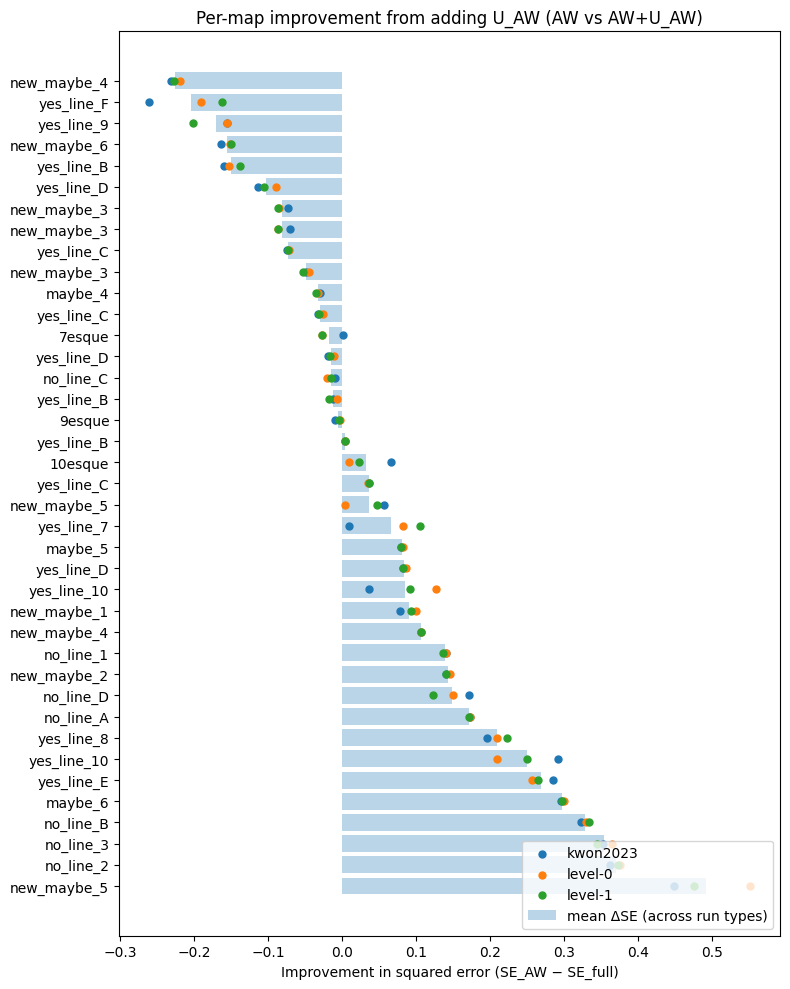

In [149]:
import matplotlib.pyplot as plt

# Keep a copy with integer index
plot_df = per_map_summary.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 10))

y_pos = np.arange(len(plot_df))

# Mean improvement bar
ax.barh(
    y_pos,
    plot_df["mean_delta_se"],
    alpha=0.3,
    label="mean ΔSE (across run types)",
)

# Add run-type-specific points
colors = {
    "kwon2023": "tab:blue",
    "level-0": "tab:orange",
    "level-1": "tab:green",
}

for rt, col in colors.items():
    if rt in plot_df.columns:
        ax.scatter(
            plot_df[rt],
            y_pos,
            label=rt,
            s=25,
            color=col,
        )

# y labels: use map_name or xp_name
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["map_name"])  # or xp_name

ax.set_xlabel("Improvement in squared error (SE_AW − SE_full)")
ax.set_title("Per-map improvement from adding U_AW (AW vs AW+U_AW)")

# Avoid duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="lower right")

plt.tight_layout()
plt.show()


In [147]:
rows = []

for rt in RUN_TYPES:
    df_rt = design_by_run[rt].copy()

    X_AW = sm.add_constant(df_rt[["aggregate_welfare"]])
    y = df_rt["rating_mean"]
    y_hat_AW = m_AW_global.predict(X_AW)

    row_full, m_full = fit_ols(
        design_df=df_rt,
        predictors=["aggregate_welfare", "univ_aggregate_welfare"],
        dv="rating_mean",
        run_type=rt,
    )

    X_full = sm.add_constant(df_rt[["aggregate_welfare", "univ_aggregate_welfare"]])
    y_hat_full = m_full.predict(X_full)

    se_AW = (y - y_hat_AW) ** 2
    se_full = (y - y_hat_full) ** 2
    delta_se = se_AW - se_full

    tmp = pd.DataFrame({
        "run_type": rt,
        "xp_name": df_rt["xp_name"],
        "map_name": df_rt.get("map_name", df_rt["xp_name"]),
        "condition": df_rt.get("condition", "NA"),
        "delta_se": delta_se,
    })

    rows.append(tmp)

per_map_long = pd.concat(rows, ignore_index=True)


In [148]:
group_cols = ["xp_name", "map_name", "condition"]

summary = (
    per_map_long
    .groupby(group_cols, as_index=False)
    .agg(
        mean_delta_se=("delta_se", "mean"),
        min_delta_se=("delta_se", "min"),
        max_delta_se=("delta_se", "max"),
    )
)

wide = (
    per_map_long
    .pivot_table(
        index=group_cols,
        columns="run_type",
        values="delta_se",
        aggfunc="mean",
    )
    .reset_index()
)

wide.columns.name = None

per_map_summary = summary.merge(wide, on=group_cols, how="left")

# Sort by average improvement
per_map_summary = per_map_summary.sort_values("mean_delta_se", ascending=False)


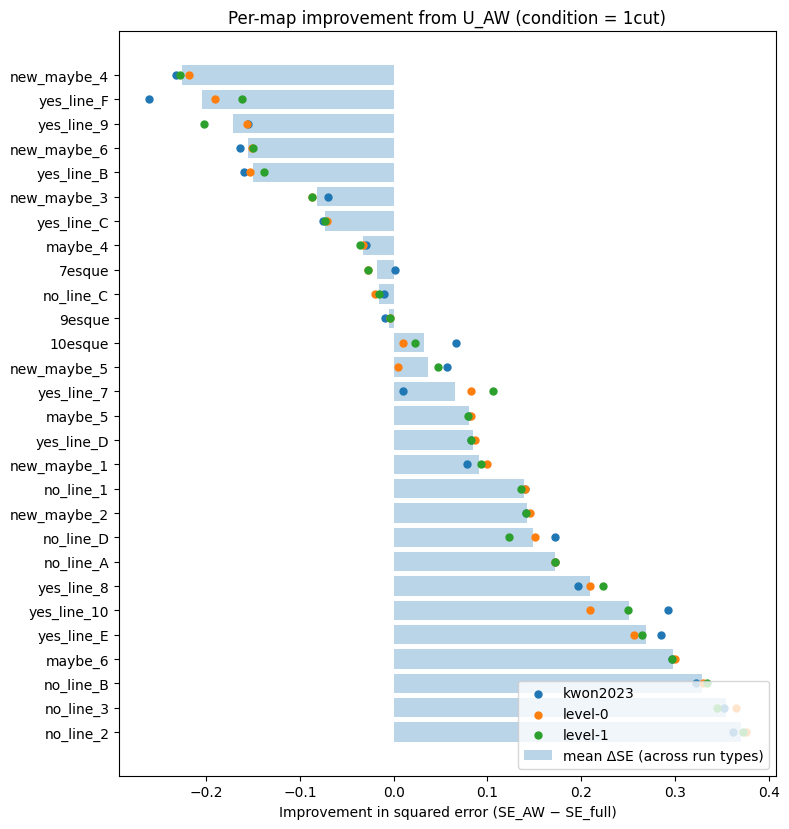

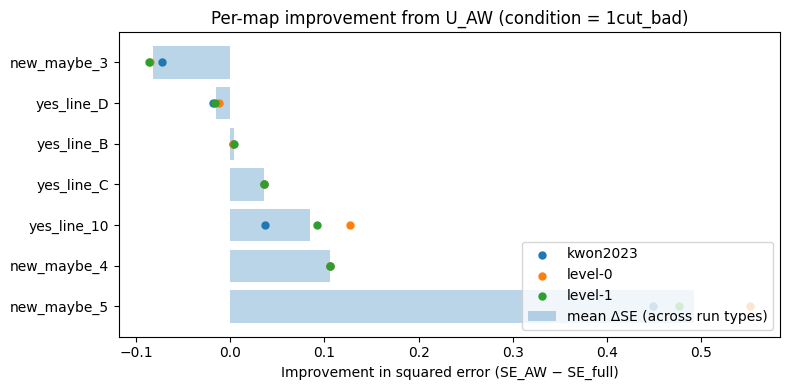

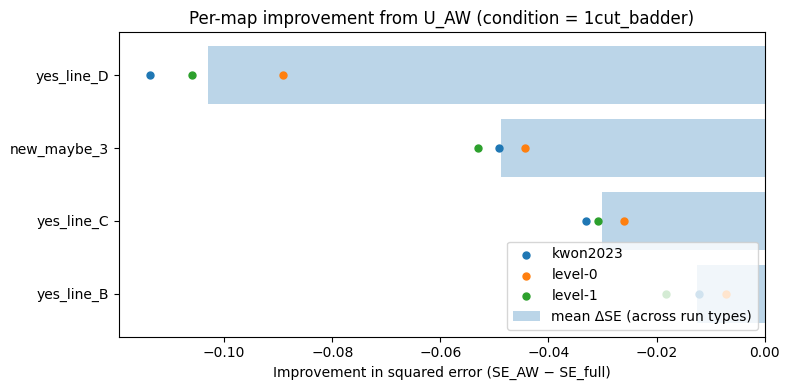

In [160]:
import matplotlib.pyplot as plt
import numpy as np

conditions = per_map_summary["condition"].unique()

for cond in sorted(conditions):
    sub = per_map_summary[per_map_summary["condition"] == cond].reset_index(drop=True)
    if sub.empty:
        continue

    fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(sub))))

    y_pos = np.arange(len(sub))

    # mean bar
    ax.barh(
        y_pos,
        sub["mean_delta_se"],
        alpha=0.3,
        label="mean ΔSE (across run types)",
    )

    colors = {
        "kwon2023": "tab:blue",
        "level-0": "tab:orange",
        "level-1": "tab:green",
    }

    for rt, col in colors.items():
        if rt in sub.columns:
            ax.scatter(
                sub[rt],
                y_pos,
                s=25,
                color=col,
                label=rt,
            )

    # Label with map_name or map_name+xp_name
    labels = sub["map_name"]  # or sub["map_name"] + " / " + sub["xp_name"]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Improvement in squared error (SE_AW − SE_full)")
    ax.set_title(f"Per-map improvement from U_AW (condition = {cond})")

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="lower right")

    fig.tight_layout()

    safe_cond = str(cond).replace("/", "-")  # avoid weird filenames
    outfile = "figures/pilot/" + f"Per_map_improvement_{safe_cond}.png"
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
# --- DRAFT: vibe-coding 2

In [128]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Pick any run_type as baseline for AW (outcomes are the same)
baseline_design = design_by_run["level-0"].copy()

# Keys for "scenario": xp_name + condition if available
group_keys = ["xp_name"]
if "condition" in baseline_design.columns:
    group_keys.append("condition")

# Fit global AW-only model
row_AW_global, m_AW_global = fit_ols(
    design_df=baseline_design,
    predictors=["aggregate_welfare"],
    dv="rating_mean",
    run_type="AW_global",
)
row_AW_global

{'n_predictors': 1,
 'predictors': 'AW',
 'run_type': 'AW_global',
 'R2': np.float64(0.6294691652309871),
 'adj_R2': np.float64(0.6194548183453381),
 'AIC': np.float64(61.299305986750554),
 'BIC': np.float64(64.62642927900984),
 'n': 39,
 'predictors_full_name': 'aggregate_welfare'}

In [129]:
per_scenario_rows = []

for rt in RUN_TYPES:
    df_rt = design_by_run[rt].copy()

    # AW prediction from global AW model
    # build the design matrix with const and AW
    X_AW = sm.add_constant(df_rt[["aggregate_welfare"]])
    y = df_rt["rating_mean"]
    y_hat_AW = m_AW_global.predict(X_AW)

    # Fit full model AW + U_AW for this run_type
    row_full, m_full = fit_ols(
        design_df=df_rt,
        predictors=["aggregate_welfare", "univ_aggregate_welfare"],
        dv="rating_mean",
        run_type=rt,
    )

    X_full = sm.add_constant(df_rt[["aggregate_welfare", "univ_aggregate_welfare"]])
    y_hat_full = m_full.predict(X_full)

    # Squared errors
    se_AW = (y - y_hat_AW) ** 2
    se_full = (y - y_hat_full) ** 2
    delta_se = se_AW - se_full  # >0 means full model improves fit

    tmp = pd.DataFrame({
        "run_type": rt,
        "xp_name": df_rt["xp_name"],
        "map_name": df_rt.get("map_name", df_rt["xp_name"]),
        "se_AW": se_AW,
        "se_full": se_full,
        "delta_se": delta_se,
    })

    # include condition if present
    if "condition" in df_rt.columns:
        tmp["condition"] = df_rt["condition"]

    per_scenario_rows.append(tmp)

per_scenario_long = pd.concat(per_scenario_rows, ignore_index=True)
per_scenario_long.head()


,run_type,xp_name,map_name,se_AW,se_full,delta_se,condition
0,kwon2023,maybe_4,maybe_4,0.007279,0.036633,-0.029354,1cut
1,kwon2023,maybe_5,maybe_5,0.095375,0.015443,0.079932,1cut
2,kwon2023,maybe_6,maybe_6,0.544948,0.248413,0.296535,1cut
3,kwon2023,new_maybe_1,new_maybe_1,0.239244,0.161043,0.078201,1cut
4,kwon2023,new_maybe_2,new_maybe_2,0.259120,0.117982,0.141138,1cut


In [130]:
# group keys: xp_name (+ condition if present)
group_cols = ["xp_name"]
if "condition" in per_scenario_long.columns:
    group_cols.append("condition")

# add map_name just for labeling
group_cols_with_label = group_cols + ["map_name"]

# mean / min / max / var of delta_se across run types
summary = (
    per_scenario_long
    .groupby(group_cols_with_label, as_index=False)
    .agg(
        mean_delta_se=("delta_se", "mean"),
        min_delta_se=("delta_se", "min"),
        max_delta_se=("delta_se", "max"),
        var_delta_se=("delta_se", "var"),
    )
)

# wide version: one column per run_type with that run_type's delta_se
pivot = (
    per_scenario_long
    .pivot_table(
        index=group_cols_with_label,
        columns="run_type",
        values="delta_se",
        aggfunc="mean",
    )
    .reset_index()
)

pivot.columns.name = None  # clean up multiindex

per_scenario_summary = summary.merge(
    pivot,
    on=group_cols_with_label,
    how="left",
)

per_scenario_summary.head()


,xp_name,condition,map_name,mean_delta_se,min_delta_se,max_delta_se,var_delta_se,kwon2023,level-0,level-1
0,maybe_4,1cut,maybe_4,-0.032553,-0.035484,-0.029354,0.000009,-0.029354,-0.032821,-0.035484
1,maybe_5,1cut,maybe_5,0.080655,0.079679,0.082355,0.000002,0.079932,0.082355,0.079679
2,maybe_6,1cut,maybe_6,0.297896,0.296535,0.300372,0.000005,0.296535,0.300372,0.296780
3,new_maybe_1,1cut,new_maybe_1,0.090592,0.078201,0.100001,0.000125,0.078201,0.100001,0.093575
4,new_maybe_2,1cut,new_maybe_2,0.142673,0.141063,0.145817,0.000007,0.141138,0.145817,0.141063


In [131]:
def categorize_scenario(row, imp_thresh=0.0, diff_thresh=0.02):
    """
    imp_thresh: minimum mean ΔSE for calling universalization "helpful"
    diff_thresh: minimum (max-min) across run_types to call it "run-type-sensitive"
    """
    mean_imp = row["mean_delta_se"]
    # get per-run-type deltas
    deltas = [row.get(rt) for rt in RUN_TYPES if pd.notna(row.get(rt))]
    if len(deltas) == 0:
        return "no_data"

    max_diff = max(deltas) - min(deltas)

    if mean_imp <= imp_thresh:
        # U_AW doesn't help (or hurts)
        return "AW_sufficient_or_univ_hurts"
    else:
        # U_AW helps on average
        if max_diff <= diff_thresh:
            return "univ_help_run_type_insensitive"
        else:
            return "univ_help_run_type_sensitive"

per_scenario_summary["category"] = per_scenario_summary.apply(
    categorize_scenario, axis=1
)

per_scenario_summary.sort_values("mean_delta_se", ascending=False).head(10)


,xp_name,condition,map_name,mean_delta_se,min_delta_se,max_delta_se,var_delta_se,kwon2023,level-0,level-1,category
11,new_maybe_5_bad,1cut_bad,new_maybe_5,0.492376,0.449142,0.551575,2.814253e-03,0.449142,0.551575,0.476412,univ_help_run_type_sensitive
14,new_no_2,1cut,no_line_2,0.370432,0.362215,0.375971,5.268741e-05,0.362215,0.375971,0.373109,univ_help_run_type_insensitive
15,new_no_3,1cut,no_line_3,0.354048,0.344595,0.365308,1.097037e-04,0.352241,0.365308,0.344595,univ_help_run_type_sensitive
25,noline_b,1cut,no_line_B,0.328680,0.322566,0.333813,3.233935e-05,0.322566,0.329660,0.333813,univ_help_run_type_insensitive
2,maybe_6,1cut,maybe_6,0.297896,0.296535,0.300372,4.615051e-06,0.296535,0.300372,0.296780,univ_help_run_type_insensitive
37,yesline_e,1cut,yes_line_E,0.269019,0.256909,0.285078,2.100663e-04,0.285078,0.256909,0.265071,univ_help_run_type_sensitive
16,new_yes_10,1cut,yes_line_10,0.250731,0.209548,0.292361,1.714667e-03,0.292361,0.209548,0.250283,univ_help_run_type_sensitive
21,new_yes_8,1cut,yes_line_8,0.209596,0.196197,0.223193,1.822234e-04,0.196197,0.209399,0.223193,univ_help_run_type_sensitive
24,noline_a,1cut,no_line_A,0.172205,0.171591,0.172544,2.840766e-07,0.172482,0.172544,0.171591,univ_help_run_type_insensitive
27,noline_d,1cut,no_line_D,0.148391,0.122890,0.171703,5.992808e-04,0.171703,0.150580,0.122890,univ_help_run_type_sensitive


In [132]:
per_scenario_summary[per_scenario_summary["category"] == "AW_sufficient_or_univ_hurts"]


,xp_name,condition,map_name,mean_delta_se,min_delta_se,max_delta_se,var_delta_se,kwon2023,level-0,level-1,category
0,maybe_4,1cut,maybe_4,-0.032553,-0.035484,-0.029354,0.000009,-0.029354,-0.032821,-0.035484,AW_sufficient_or_univ_hurts
5,new_maybe_3,1cut,new_maybe_3,-0.081277,-0.086737,-0.070444,0.000088,-0.070444,-0.086737,-0.086649,AW_sufficient_or_univ_hurts
6,new_maybe_3_bad,1cut_bad,new_maybe_3,-0.081518,-0.086351,-0.072764,0.000058,-0.072764,-0.085439,-0.086351,AW_sufficient_or_univ_hurts
7,new_maybe_3_badder,1cut_badder,new_maybe_3,-0.048846,-0.052976,-0.044437,0.000018,-0.049125,-0.044437,-0.052976,AW_sufficient_or_univ_hurts
8,new_maybe_4,1cut,new_maybe_4,-0.225950,-0.231747,-0.218761,0.000044,-0.231747,-0.218761,-0.227341,AW_sufficient_or_univ_hurts
12,new_maybe_6,1cut,new_maybe_6,-0.155209,-0.163980,-0.150331,0.000058,-0.163980,-0.151316,-0.150331,AW_sufficient_or_univ_hurts
20,new_yes_7esque,1cut,7esque,-0.017793,-0.027802,0.001329,0.000274,0.001329,-0.026906,-0.027802,AW_sufficient_or_univ_hurts
22,new_yes_9,1cut,yes_line_9,-0.171049,-0.201859,-0.155122,0.000712,-0.155122,-0.156165,-0.201859,AW_sufficient_or_univ_hurts
23,new_yes_9esque,1cut,9esque,-0.005367,-0.009065,-0.003466,0.000010,-0.009065,-0.003466,-0.003569,AW_sufficient_or_univ_hurts
26,noline_c,1cut,no_line_C,-0.015150,-0.019941,-0.009965,0.000025,-0.009965,-0.019941,-0.015545,AW_sufficient_or_univ_hurts


In [133]:
per_scenario_summary[per_scenario_summary["category"] == "univ_help_run_type_insensitive"]


,xp_name,condition,map_name,mean_delta_se,min_delta_se,max_delta_se,var_delta_se,kwon2023,level-0,level-1,category
1,maybe_5,1cut,maybe_5,0.080655,0.079679,0.082355,2.182907e-06,0.079932,0.082355,0.079679,univ_help_run_type_insensitive
2,maybe_6,1cut,maybe_6,0.297896,0.296535,0.300372,4.615051e-06,0.296535,0.300372,0.296780,univ_help_run_type_insensitive
4,new_maybe_2,1cut,new_maybe_2,0.142673,0.141063,0.145817,7.416801e-06,0.141138,0.145817,0.141063,univ_help_run_type_insensitive
9,new_maybe_4_bad,1cut_bad,new_maybe_4,0.106207,0.106193,0.106232,4.466507e-10,0.106193,0.106232,0.106197,univ_help_run_type_insensitive
13,new_no_1,1cut,no_line_1,0.138837,0.135981,0.140277,6.118169e-06,0.140253,0.140277,0.135981,univ_help_run_type_insensitive
14,new_no_2,1cut,no_line_2,0.370432,0.362215,0.375971,5.268741e-05,0.362215,0.375971,0.373109,univ_help_run_type_insensitive
24,noline_a,1cut,no_line_A,0.172205,0.171591,0.172544,2.840766e-07,0.172482,0.172544,0.171591,univ_help_run_type_insensitive
25,noline_b,1cut,no_line_B,0.328680,0.322566,0.333813,3.233935e-05,0.322566,0.329660,0.333813,univ_help_run_type_insensitive
29,yesline_b_bad,1cut_bad,yes_line_B,0.003468,0.003391,0.003623,1.793001e-08,0.003391,0.003391,0.003623,univ_help_run_type_insensitive
32,yesline_c_bad,1cut_bad,yes_line_C,0.035881,0.035657,0.036274,1.162959e-07,0.036274,0.035657,0.035714,univ_help_run_type_insensitive


In [134]:
per_scenario_summary[per_scenario_summary["category"] == "univ_help_run_type_sensitive"]


,xp_name,condition,map_name,mean_delta_se,min_delta_se,max_delta_se,var_delta_se,kwon2023,level-0,level-1,category
3,new_maybe_1,1cut,new_maybe_1,0.090592,0.078201,0.100001,0.000125,0.078201,0.100001,0.093575,univ_help_run_type_sensitive
10,new_maybe_5,1cut,new_maybe_5,0.036261,0.004501,0.056890,0.000779,0.056890,0.004501,0.047394,univ_help_run_type_sensitive
11,new_maybe_5_bad,1cut_bad,new_maybe_5,0.492376,0.449142,0.551575,0.002814,0.449142,0.551575,0.476412,univ_help_run_type_sensitive
15,new_no_3,1cut,no_line_3,0.354048,0.344595,0.365308,0.000110,0.352241,0.365308,0.344595,univ_help_run_type_sensitive
16,new_yes_10,1cut,yes_line_10,0.250731,0.209548,0.292361,0.001715,0.292361,0.209548,0.250283,univ_help_run_type_sensitive
17,new_yes_10_bad,1cut_bad,yes_line_10,0.085122,0.036783,0.126922,0.002063,0.036783,0.126922,0.091661,univ_help_run_type_sensitive
18,new_yes_10mod,1cut,10esque,0.032787,0.009478,0.066384,0.000889,0.066384,0.009478,0.022499,univ_help_run_type_sensitive
19,new_yes_7,1cut,yes_line_7,0.065882,0.009828,0.105693,0.002495,0.009828,0.082125,0.105693,univ_help_run_type_sensitive
21,new_yes_8,1cut,yes_line_8,0.209596,0.196197,0.223193,0.000182,0.196197,0.209399,0.223193,univ_help_run_type_sensitive
27,noline_d,1cut,no_line_D,0.148391,0.122890,0.171703,0.000599,0.171703,0.150580,0.122890,univ_help_run_type_sensitive


In [141]:
from analysis_utils import _map_type

per_scenario_summary["map_type"] = per_scenario_summary["map_name"].apply(_map_type)


pd.crosstab(
    per_scenario_summary["category"],
    per_scenario_summary["map_type"]
)

map_type,maybe,no_line,yes_line
category,,,
AW_sufficient_or_univ_hurts,8,1,8
univ_help_run_type_insensitive,4,4,3
univ_help_run_type_sensitive,4,2,5


In [142]:
per_scenario_summary[
    per_scenario_summary["map_type"] == "yes_line"
].sort_values("mean_delta_se", ascending=False)


,xp_name,condition,map_name,mean_delta_se,min_delta_se,max_delta_se,var_delta_se,kwon2023,level-0,level-1,category,map_type
37,yesline_e,1cut,yes_line_E,0.269019,0.256909,0.285078,2.100663e-04,0.285078,0.256909,0.265071,univ_help_run_type_sensitive,yes_line
16,new_yes_10,1cut,yes_line_10,0.250731,0.209548,0.292361,1.714667e-03,0.292361,0.209548,0.250283,univ_help_run_type_sensitive,yes_line
21,new_yes_8,1cut,yes_line_8,0.209596,0.196197,0.223193,1.822234e-04,0.196197,0.209399,0.223193,univ_help_run_type_sensitive,yes_line
17,new_yes_10_bad,1cut_bad,yes_line_10,0.085122,0.036783,0.126922,2.063335e-03,0.036783,0.126922,0.091661,univ_help_run_type_sensitive,yes_line
34,yesline_d,1cut,yes_line_D,0.084238,0.082890,0.086932,5.441556e-06,0.082893,0.086932,0.082890,univ_help_run_type_insensitive,yes_line
19,new_yes_7,1cut,yes_line_7,0.065882,0.009828,0.105693,2.495404e-03,0.009828,0.082125,0.105693,univ_help_run_type_sensitive,yes_line
32,yesline_c_bad,1cut_bad,yes_line_C,0.035881,0.035657,0.036274,1.162959e-07,0.036274,0.035657,0.035714,univ_help_run_type_insensitive,yes_line
29,yesline_b_bad,1cut_bad,yes_line_B,0.003468,0.003391,0.003623,1.793001e-08,0.003391,0.003391,0.003623,univ_help_run_type_insensitive,yes_line
30,yesline_b_badder,1cut_badder,yes_line_B,-0.012527,-0.018215,-0.007202,3.042122e-05,-0.012165,-0.007202,-0.018215,AW_sufficient_or_univ_hurts,yes_line
35,yesline_d_bad,1cut_bad,yes_line_D,-0.015476,-0.018415,-0.011591,1.231552e-05,-0.018415,-0.011591,-0.016423,AW_sufficient_or_univ_hurts,yes_line


In [ ]:
# --- From overall fit to experiment notebook (all maps each time) --- #

In [4]:
# --- Best model exploration --- #

In [5]:
# Best model using only outcome measures (from actual line-cutting scenarios seen by participants)
summary_baseline = compare_models(design_by_run["kwon2023"], predictors=OUTCOME_COLS, run_type="N/A", dv="rating_mean")
summary_baseline

# Best model is simple regression with aggregate_welfare (R2=.629; BIC=64.6).

# Second best: AW + OH. (R2=.636; BIC=67.6) [NB: OH by itself is super bad, it explains less thant 3% of variance]
# Next: AW + Ineq, AW + Gini, AW + CH, CH only [CH is systematically the second best predictor for simple reg]

# Kwon2023 model, with four outcome variables (not gini) gives you marginally higher correlation (R2 += .035), and is penalized (BIC += 11)

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,N/A,0.629469,0.619455,61.299306,64.626429,39,aggregate_welfare
7,2,AW+OH,N/A,0.636171,0.615958,62.587446,67.578131,39,aggregate_welfare+ordinal_harm_blind
5,2,AW+Ineq,N/A,0.630512,0.609985,63.189425,68.180110,39,aggregate_welfare+inequality
8,2,AW+Gini,N/A,0.629938,0.609379,63.249888,68.240573,39,aggregate_welfare+gini
6,2,AW+CH,N/A,0.629642,0.609067,63.281087,68.271772,39,aggregate_welfare+cardinal_harm
2,1,CH,N/A,0.580424,0.569084,66.147305,69.474429,39,cardinal_harm
18,3,AW+CH+OH,N/A,0.651751,0.621901,62.880532,69.534778,39,aggregate_welfare+cardinal_harm+ordinal_harm_b...
16,3,AW+Ineq+OH,N/A,0.638742,0.607777,64.310833,70.965079,39,aggregate_welfare+inequality+ordinal_harm_blind
20,3,AW+OH+Gini,N/A,0.637690,0.606635,64.424276,71.078523,39,aggregate_welfare+ordinal_harm_blind+gini
17,3,AW+Ineq+Gini,N/A,0.630650,0.598992,65.174775,71.829022,39,aggregate_welfare+inequality+gini


In [37]:
# Best model using aggregate welfare (best outcome-only model) and univeralization measures from kwon2023
summary_kwon2023 = compare_models(design_by_run["kwon2023"], predictors=["aggregate_welfare"]+UNIV_COLS, run_type="kwon2023", dv="rating_mean")
summary_kwon2023

# Best model adds just univ_aggregate welfare (R2 = .714, BIC = 58.1)
# Second best: add U_AW and U_CH (R2 =.731, BIC=59.5)
# (Next: add U_AW and U_Gini / U_AW and U_Ineq / or just U_CH)

# U_AW alone: R2= 0.381760	 / BIC= 84.592110	
# Then U_CH 

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
6,2,AW+U_AW,kwon2023,0.714412,0.698546,53.144180,58.134865,39,aggregate_welfare+univ_aggregate_welfare
22,3,AW+U_AW+U_CH,kwon2023,0.730805,0.707731,52.838782,59.493028,39,aggregate_welfare+univ_aggregate_welfare+univ_...
24,3,AW+U_AW+U_Gini,kwon2023,0.722019,0.698192,54.091323,60.745570,39,aggregate_welfare+univ_aggregate_welfare+univ_...
21,3,AW+U_AW+U_Ineq,kwon2023,0.721530,0.697661,54.159923,60.814170,39,aggregate_welfare+univ_aggregate_welfare+univ_...
8,2,AW+U_CH,kwon2023,0.693524,0.676498,55.897172,60.887857,39,aggregate_welfare+univ_cardinal_harm
...,...,...,...,...,...,...,...,...,...
16,2,U_Ineq+U_OH,kwon2023,0.199780,0.155323,93.327375,98.318060,39,univ_inequality+univ_ordinal_harm_blind
39,3,U_Ineq+U_OH+U_Gini,kwon2023,0.266732,0.203880,91.919733,98.573980,39,univ_inequality+univ_ordinal_harm_blind+univ_gini
5,1,U_Gini,kwon2023,0.066758,0.041535,97.324702,100.651825,39,univ_gini
4,1,U_OH,kwon2023,0.007411,-0.019416,99.729142,103.056265,39,univ_ordinal_harm_blind


In [55]:
# Best model using all outcome metrics and all univeralization measures from kwon2023
summary_kwon2023_full = compare_models(design_by_run["kwon2023"], predictors=OUTCOME_COLS+ UNIV_COLS, run_type="kwon2023", dv="rating_mean")
summary_kwon2023_full.head(10)
#summary_kwon2023_full[ summary_kwon2023_full [ "n_predictors" ] == 1]
# Overall, best model remains AW + U_AW
# Next (close): CH + U_AW + U_CH / AW + U_AW + U_CH (BIC+1)

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,kwon2023,0.629469,0.619455,61.299306,64.626429,39,aggregate_welfare
2,1,CH,kwon2023,0.580424,0.569084,66.147305,69.474429,39,cardinal_harm
5,1,U_AW,kwon2023,0.381760,0.365051,81.264987,84.592110,39,univ_aggregate_welfare
4,1,Gini,kwon2023,0.346767,0.329112,83.412199,86.739322,39,gini
7,1,U_CH,kwon2023,0.291209,0.272052,86.595660,89.922783,39,univ_cardinal_harm
6,1,U_Ineq,kwon2023,0.182211,0.160109,92.174343,95.501466,39,univ_inequality
9,1,U_Gini,kwon2023,0.066758,0.041535,97.324702,100.651825,39,univ_gini
1,1,Ineq,kwon2023,0.040803,0.014879,98.394542,101.721665,39,inequality
3,1,OH,kwon2023,0.028557,0.002302,98.889281,102.216405,39,ordinal_harm_blind
8,1,U_OH,kwon2023,0.007411,-0.019416,99.729142,103.056265,39,univ_ordinal_harm_blind


In [53]:
# Best model using aggregate welfare (best outcome-only model) and univeralization measures from level-0
summary_lvl_0 = compare_models(design_by_run["level-0"], predictors=["aggregate_welfare"]+UNIV_COLS, run_type="level-0", dv="rating_mean")
summary_lvl_0 [ summary_lvl_0[ "n_predictors" ]==1 ]
#summary_lvl_0 
# Best model adds just univ_aggregate welfare (R2 = .722, BIC = 57.1)
# Second best: add U_AW and U_Ineq (R2 =.741, BIC=58)
# (Next: add U_AW and U_CH / U_AW and U_Gini / or just U_CH)

# U_AW alone: R2=35.6, BIC=86.2
# U_CH alone: R2=23.8, BIC=91.7 / Ineq ok / Gini small /  OH ridiculous

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,level-0,0.629469,0.619455,61.299306,64.626429,39,aggregate_welfare
1,1,U_AW,level-0,0.356533,0.339142,82.824743,86.151866,39,univ_aggregate_welfare
3,1,U_CH,level-0,0.258296,0.238249,88.365859,91.692982,39,univ_cardinal_harm
2,1,U_Ineq,level-0,0.169212,0.146758,92.789405,96.116528,39,univ_inequality
5,1,U_Gini,level-0,0.062992,0.037668,97.481753,100.808876,39,univ_gini
4,1,U_OH,level-0,0.018208,-0.008327,99.302592,102.629715,39,univ_ordinal_harm_blind


In [9]:
# Best model using all outcome metrics and all univeralization measures from level-0
summary_lvl_0_full = compare_models(design_by_run["level-0"], predictors=OUTCOME_COLS+UNIV_COLS, run_type="level-0", dv="rating_mean")
summary_lvl_0_full.head(10)

# Best model is still AW+U_AW
# Second best (very close, BIC+.8): AW+U_AW+U_Ineq
# Next: AW+U_AW+U_CH / AW+U_AW+U_Gini/ CH+U_AW+U_CH (BIC increase <= 1.5)

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
14,2,AW+U_AW,level-0,0.721737,0.706278,52.130849,57.121534,39,aggregate_welfare+univ_aggregate_welfare
81,3,AW+U_AW+U_Ineq,level-0,0.741183,0.718998,51.305562,57.959808,39,aggregate_welfare+univ_aggregate_welfare+univ_...
82,3,AW+U_AW+U_CH,level-0,0.737540,0.715044,51.850565,58.504812,39,aggregate_welfare+univ_aggregate_welfare+univ_...
84,3,AW+U_AW+U_Gini,level-0,0.736110,0.713491,52.062563,58.716810,39,aggregate_welfare+univ_aggregate_welfare+univ_...
131,3,CH+U_AW+U_CH,level-0,0.735088,0.712381,52.213266,58.867513,39,cardinal_harm+univ_aggregate_welfare+univ_card...
16,2,AW+U_CH,level-0,0.700828,0.684207,54.956513,59.947198,39,aggregate_welfare+univ_cardinal_harm
58,3,AW+Ineq+U_AW,level-0,0.727482,0.704123,53.317237,59.971483,39,aggregate_welfare+inequality+univ_aggregate_we...
83,3,AW+U_AW+U_OH,level-0,0.722597,0.698819,54.010195,60.664441,39,aggregate_welfare+univ_aggregate_welfare+univ_...
71,3,AW+OH+U_AW,level-0,0.722593,0.698815,54.010727,60.664973,39,aggregate_welfare+ordinal_harm_blind+univ_aggr...
76,3,AW+Gini+U_AW,level-0,0.722397,0.698603,54.038209,60.692456,39,aggregate_welfare+gini+univ_aggregate_welfare


In [54]:
# Best model using aggregate welfare (best outcome-only model) and univeralization measures from level-0
summary_lvl_1 = compare_models(design_by_run["level-1"], predictors=["aggregate_welfare"]+UNIV_COLS, run_type="level-1", dv="rating_mean")
summary_lvl_1 
summary_lvl_1 [summary_lvl_1 ["n_predictors"]==1]
# Best model adds just univ_aggregate welfare (R2 = .718, BIC = 57.6)
# Second best: add U_AW and U_Ineq (R2 =.733, BIC=59.1)
# (Next: add U_AW and U_Gini / U_AW and U_GCH / or just U_CH)

# U_AW alone: 37.2%, BIC=85.2
# U_CH alone: 

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
0,1,AW,level-1,0.629469,0.619455,61.299306,64.626429,39,aggregate_welfare
1,1,U_AW,level-1,0.372141,0.355171,81.867116,85.194239,39,univ_aggregate_welfare
3,1,U_CH,level-1,0.287040,0.267771,86.824343,90.151466,39,univ_cardinal_harm
2,1,U_Ineq,level-1,0.173106,0.150758,92.606144,95.933267,39,univ_inequality
5,1,U_Gini,level-1,0.046272,0.020496,98.171529,101.498652,39,univ_gini
4,1,U_OH,level-1,0.031991,0.005829,98.751183,102.078306,39,univ_ordinal_harm_blind


In [11]:
# Best model using all outcome metrics and all univeralization measures from level-1
summary_lvl_1_full = compare_models(design_by_run["level-1"], predictors=OUTCOME_COLS+UNIV_COLS, run_type="level-1", dv="rating_mean")
summary_lvl_1_full.head(10)

# Best model is still AW+U_AW
# Next: AW+U_AW+U_Ineq / W+U_AW+U_Gini / AW+U_AW+U_CH / AW+U_AW+U_CH	 (1.5 <= BIC increase <= 2)

,n_predictors,predictors,run_type,R2,adj_R2,AIC,BIC,n,predictors_full_name
14,2,AW+U_AW,level-1,0.718028,0.702363,52.647226,57.637911,39,aggregate_welfare+univ_aggregate_welfare
81,3,AW+U_AW+U_Ineq,level-1,0.733459,0.710612,52.452398,59.106644,39,aggregate_welfare+univ_aggregate_welfare+univ_...
84,3,AW+U_AW+U_Gini,level-1,0.729695,0.706526,52.999204,59.653450,39,aggregate_welfare+univ_aggregate_welfare+univ_...
82,3,AW+U_AW+U_CH,level-1,0.729573,0.706394,53.016797,59.671044,39,aggregate_welfare+univ_aggregate_welfare+univ_...
16,2,AW+U_CH,level-1,0.700125,0.683466,55.047975,60.038660,39,aggregate_welfare+univ_cardinal_harm
131,3,CH+U_AW+U_CH,level-1,0.725673,0.702159,53.575293,60.229540,39,cardinal_harm+univ_aggregate_welfare+univ_card...
58,3,AW+Ineq+U_AW,level-1,0.723563,0.699868,53.874110,60.528356,39,aggregate_welfare+inequality+univ_aggregate_we...
71,3,AW+OH+U_AW,level-1,0.719242,0.695177,54.478947,61.133193,39,aggregate_welfare+ordinal_harm_blind+univ_aggr...
76,3,AW+Gini+U_AW,level-1,0.718721,0.694612,54.551245,61.205491,39,aggregate_welfare+gini+univ_aggregate_welfare
83,3,AW+U_AW+U_OH,level-1,0.718331,0.694188,54.605349,61.259595,39,aggregate_welfare+univ_aggregate_welfare+univ_...


In [12]:
# - Draft ln likehood stuff

In [13]:
from scipy import stats

def lr_test(m_small, m_big):
    """
    Likelihood-ratio test for nested OLS models.
    m_small: restricted model
    m_big:   full model (includes all predictors in m_small)

    Returns: (statistic, df, p_value)
    """
    ll_small = m_small.llf
    ll_big = m_big.llf

    # number of parameters (including intercept) is len(.params)
    k_small = len(m_small.params)
    k_big = len(m_big.params)
    df = k_big - k_small

    if df <= 0:
        raise ValueError("m_big must have more parameters than m_small.")

    stat = 2 * (ll_big - ll_small)
    p = stats.chi2.sf(stat, df)
    return stat, df, p


In [14]:
design = design_by_run["kwon2023"]

# 1) AW
row_aw, m_aw = fit_ols(design, ["aggregate_welfare"], dv="rating_mean", run_type="level-1")

# 2) AW + U_AW
row_aw_uaw, m_aw_uaw = fit_ols(
    design,
    ["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_type="level-1",
)

# 3) AW + U_AW + U_Ineq
row_aw_uaw_uineq, m_aw_uaw_uineq = fit_ols(
    design,
    ["aggregate_welfare", "univ_aggregate_welfare", "univ_inequality"],
    dv="rating_mean",
    run_type="level-1",
)

# LR tests
print("AW vs AW+U_AW:", lr_test(m_aw, m_aw_uaw))
print("AW+U_AW vs AW+U_AW+U_Ineq:", lr_test(m_aw_uaw, m_aw_uaw_uineq))

# For all 3 run types: adding U_AW is significantly better; Adding U_Ineq after doesn't significantly improve the model

AW vs AW+U_AW: (np.float64(10.155125527325502), 1, np.float64(0.00143900597352762))
AW+U_AW vs AW+U_AW+U_Ineq: (np.float64(0.984257202259549), 1, np.float64(0.32115002673823334))


In [15]:
# --- Draft: model comparison for small subset, with ln-likelihood column

In [27]:
import pandas as pd

design0 = design_by_run["level-0"]

models_lvl0 = {}

# M0: AW
row_M0, m_M0 = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M0_AW"] = (row_M0, m_M0)

# M1: AW + U_AW
row_M1, m_M1 = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M1_AW+U_AW"] = (row_M1, m_M1)

# M2a: AW + U_AW + U_Ineq
row_M2a, m_M2a = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_inequality"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M2a_AW+U_AW+U_Ineq"] = (row_M2a, m_M2a)

# M2b: AW + U_AW + U_CH
row_M2b, m_M2b = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_cardinal_harm"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M2b_AW+U_AW+U_CH"] = (row_M2b, m_M2b)

# M2c: AW + U_AW + U_Gini
row_M2c, m_M2c = fit_ols(
    design_df=design0,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_gini"],
    dv="rating_mean",
    run_type="level-0",
)
models_lvl0["M2c_AW+U_AW+U_Gini"] = (row_M2c, m_M2c)

# Put rows in a DataFrame
rows = []
for name, (row, model) in models_lvl0.items():
    r = row.copy()
    r["model_id"] = name
    r["logLik"] = model.llf
    rows.append(r)

tbl_lvl0 = pd.DataFrame(rows)

# Add ΔBIC relative to best
best_bic = tbl_lvl0["BIC"].min()
tbl_lvl0["delta_BIC"] = tbl_lvl0["BIC"] - best_bic

# Add LR tests:
# - M0 vs M1
# - M1 vs each M2*
tbl_lvl0["lr_ref"] = None
tbl_lvl0["lr_stat"] = None
tbl_lvl0["lr_df"] = None
tbl_lvl0["lr_p"] = None

def set_lr_row(df, model_from, model_to, ref_name):
    stat, df_lr, p = lr_test(models_lvl0[model_from][1],
                             models_lvl0[model_to][1])
    idx = df["model_id"] == model_to
    df.loc[idx, "lr_ref"] = ref_name
    df.loc[idx, "lr_stat"] = stat
    df.loc[idx, "lr_df"] = df_lr
    df.loc[idx, "lr_p"] = p

# AW vs AW+U_AW
set_lr_row(tbl_lvl0, "M0_AW", "M1_AW+U_AW", ref_name="M0_AW")

# AW+U_AW vs each 3-predictor model
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2a_AW+U_AW+U_Ineq", ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2b_AW+U_AW+U_CH",   ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2c_AW+U_AW+U_Gini", ref_name="M1_AW+U_AW")

# For display: pick columns & order
cols = [
    "model_id",
    "predictors",           # your short labels, e.g. AW+U_AW
    "n_predictors",
    "R2",
    "adj_R2",
    "AIC",
    "BIC",
    "delta_BIC",
    "lr_ref",
    "lr_stat",
    "lr_df",
    "lr_p",
]
tbl_lvl0_display = tbl_lvl0[cols].sort_values("BIC")

# Pull out M0 row
m0 = tbl_lvl0_display[tbl_lvl0_display["model_id"] == "M0_AW"]
rest = tbl_lvl0_display[tbl_lvl0_display["model_id"] != "M0_AW"]

# Recombine with M0 first
tbl_lvl0_display = pd.concat([m0, rest], ignore_index=True)
tbl_lvl0_display


,model_id,predictors,n_predictors,R2,adj_R2,AIC,BIC,delta_BIC,lr_ref,lr_stat,lr_df,lr_p
0,M0_AW,AW,1,0.629469,0.619455,61.299306,64.626429,7.504895,None,None,None,None
1,M1_AW+U_AW,AW+U_AW,2,0.721737,0.706278,52.130849,57.121534,0.000000,M0_AW,11.168457,1,0.000832
2,M2a_AW+U_AW+U_Ineq,AW+U_AW+U_Ineq,3,0.741183,0.718998,51.305562,57.959808,0.838275,M1_AW+U_AW,2.825287,1,0.09279
3,M2b_AW+U_AW+U_CH,AW+U_AW+U_CH,3,0.737540,0.715044,51.850565,58.504812,1.383278,M1_AW+U_AW,2.280284,1,0.131028
4,M2c_AW+U_AW+U_Gini,AW+U_AW+U_Gini,3,0.736110,0.713491,52.062563,58.716810,1.595276,M1_AW+U_AW,2.068286,1,0.150391


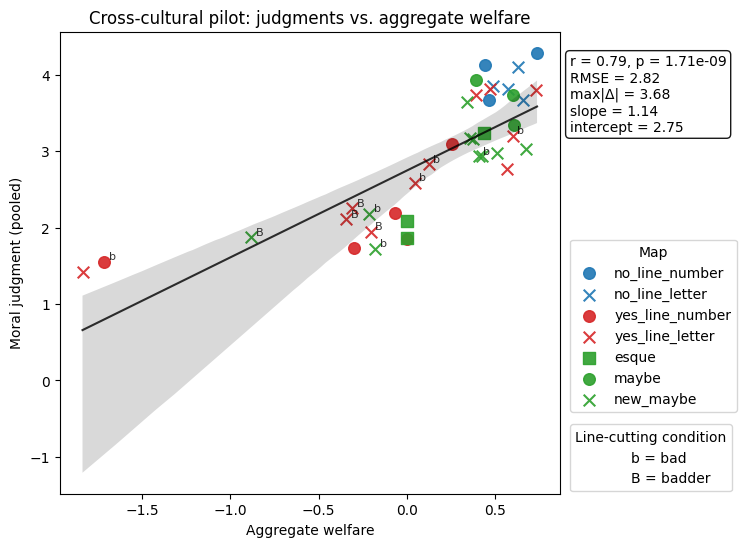

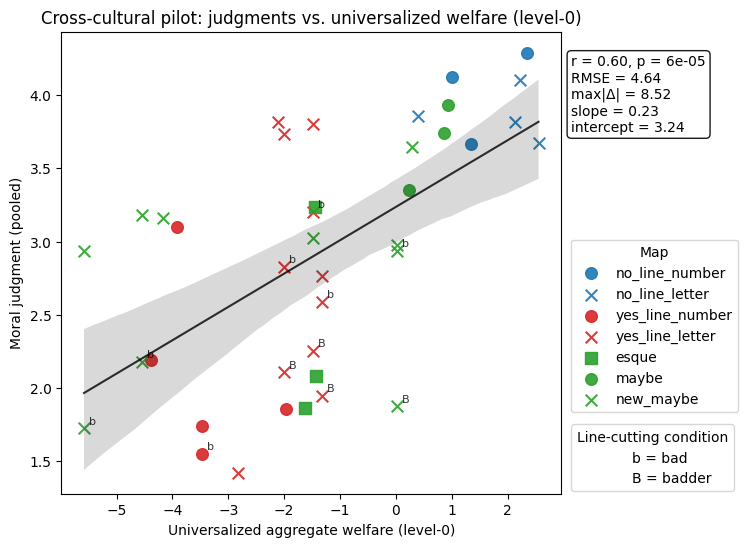

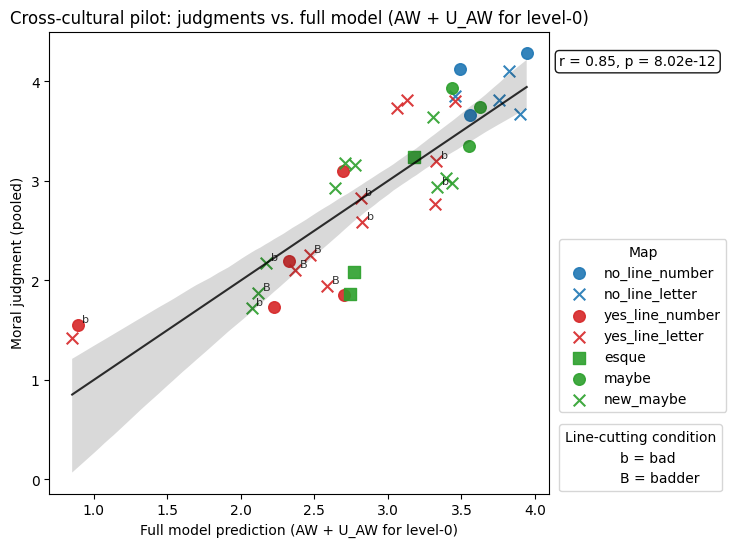

In [28]:
# --- Draft: make figure 5 style plots 

# Add predictions to the design df
design0 = design0.copy()
design0["pred_M0"] = models_lvl0["M0_AW"][1].fittedvalues
design0["pred_M1"] = models_lvl0["M1_AW+U_AW"][1].fittedvalues

#AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design0,
    x_col="aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. aggregate welfare",
    xlabel="Aggregate welfare",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_AW.png",
    display_line_cutting_condition=True,
    fit_regression=True
)

#U_AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design0,
    x_col="univ_aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. universalized welfare (level-0)",
    xlabel="Universalized aggregate welfare (level-0)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_UW_lvl0",
    display_line_cutting_condition=True,
    fit_regression=True
)

# AW + U_AW (do not refit the regressoin; just showing regrssion of y_predicted against y)
fig2, ax2 = plot_simple_regression(
    design0,
    x_col="pred_M1",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. full model (AW + U_AW for level-0)",
    xlabel="Full model prediction (AW + U_AW for level-0)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_full_lvl0",
    display_line_cutting_condition=True,
    fit_regression=False
)



In [35]:
from math import sqrt
r_1 = 0.718028
r_0 = 0.721737
r_k = 0.714412

print(sqrt(r_1), sqrt(r_0), sqrt(r_k))

0.847365328533095 0.8495510579123541 0.8452289630626721


,model_id,predictors,n_predictors,R2,adj_R2,AIC,BIC,delta_BIC,lr_ref,lr_stat,lr_df,lr_p
0,M0_AW,AW,1,0.629469,0.619455,61.299306,64.626429,6.988519,None,None,None,None
1,M1_AW+U_AW,AW+U_AW,2,0.718028,0.702363,52.647226,57.637911,0.000000,M0_AW,10.65208,1,0.001099
2,M2a_AW+U_AW+U_Ineq,AW+U_AW+U_Ineq,3,0.733459,0.710612,52.452398,59.106644,1.468734,M1_AW+U_AW,2.194828,1,0.138475
3,M2c_AW+U_AW+U_Gini,AW+U_AW+U_Gini,3,0.729695,0.706526,52.999204,59.653450,2.015540,M1_AW+U_AW,1.648022,1,0.199228
4,M2b_AW+U_AW+U_CH,AW+U_AW+U_CH,3,0.729573,0.706394,53.016797,59.671044,2.033133,M1_AW+U_AW,1.630429,1,0.201644


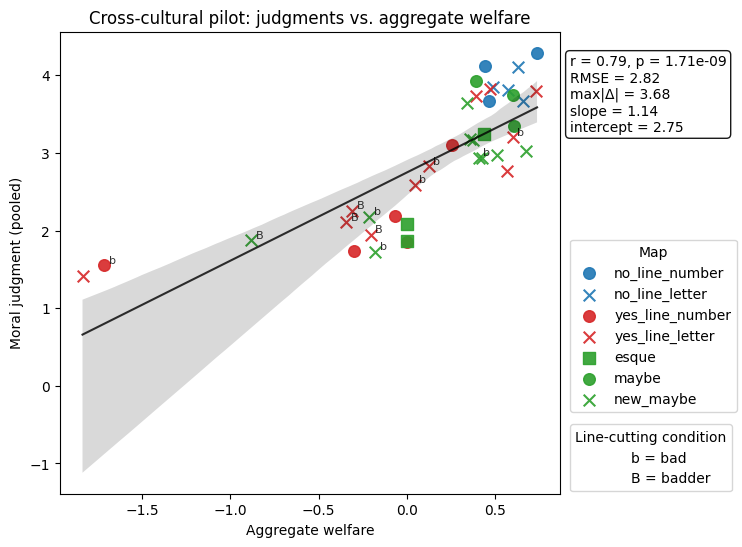

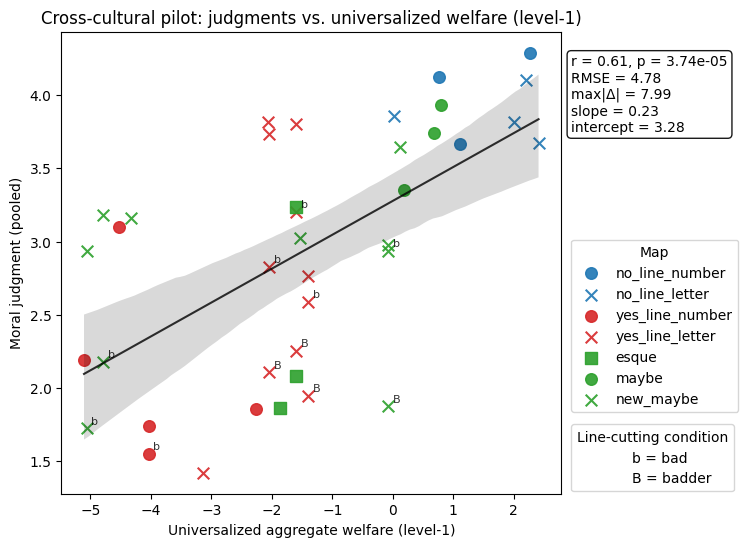

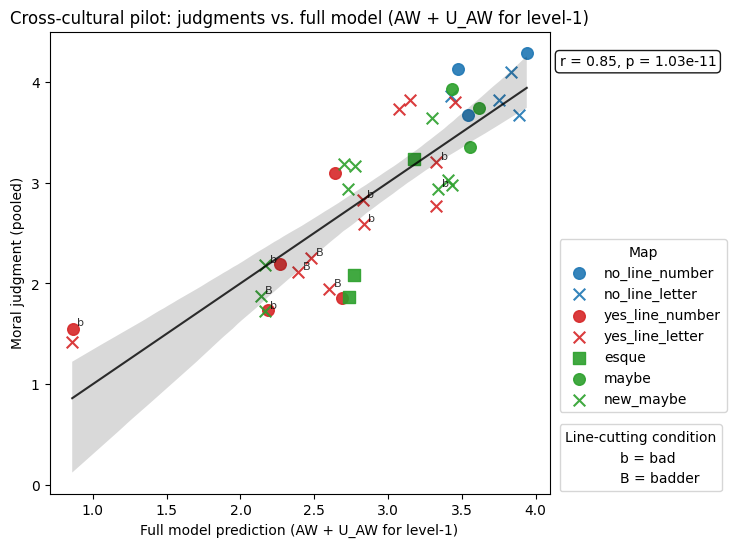

In [30]:
### --- redo for level 1


design1 = design_by_run["level-1"]

models_lvl0 = {}

# M0: AW
row_M0, m_M0 = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M0_AW"] = (row_M0, m_M0)

# M1: AW + U_AW
row_M1, m_M1 = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M1_AW+U_AW"] = (row_M1, m_M1)

# M2a: AW + U_AW + U_Ineq
row_M2a, m_M2a = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_inequality"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M2a_AW+U_AW+U_Ineq"] = (row_M2a, m_M2a)

# M2b: AW + U_AW + U_CH
row_M2b, m_M2b = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_cardinal_harm"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M2b_AW+U_AW+U_CH"] = (row_M2b, m_M2b)

# M2c: AW + U_AW + U_Gini
row_M2c, m_M2c = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_gini"],
    dv="rating_mean",
    run_type="level-1",
)
models_lvl0["M2c_AW+U_AW+U_Gini"] = (row_M2c, m_M2c)

# Put rows in a DataFrame
rows = []
for name, (row, model) in models_lvl0.items():
    r = row.copy()
    r["model_id"] = name
    r["logLik"] = model.llf
    rows.append(r)

tbl_lvl0 = pd.DataFrame(rows)

# Add ΔBIC relative to best
best_bic = tbl_lvl0["BIC"].min()
tbl_lvl0["delta_BIC"] = tbl_lvl0["BIC"] - best_bic

# Add LR tests:
# - M0 vs M1
# - M1 vs each M2*
tbl_lvl0["lr_ref"] = None
tbl_lvl0["lr_stat"] = None
tbl_lvl0["lr_df"] = None
tbl_lvl0["lr_p"] = None

def set_lr_row(df, model_from, model_to, ref_name):
    stat, df_lr, p = lr_test(models_lvl0[model_from][1],
                             models_lvl0[model_to][1])
    idx = df["model_id"] == model_to
    df.loc[idx, "lr_ref"] = ref_name
    df.loc[idx, "lr_stat"] = stat
    df.loc[idx, "lr_df"] = df_lr
    df.loc[idx, "lr_p"] = p

# AW vs AW+U_AW
set_lr_row(tbl_lvl0, "M0_AW", "M1_AW+U_AW", ref_name="M0_AW")

# AW+U_AW vs each 3-predictor model
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2a_AW+U_AW+U_Ineq", ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2b_AW+U_AW+U_CH",   ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2c_AW+U_AW+U_Gini", ref_name="M1_AW+U_AW")

# For display: pick columns & order
cols = [
    "model_id",
    "predictors",           # your short labels, e.g. AW+U_AW
    "n_predictors",
    "R2",
    "adj_R2",
    "AIC",
    "BIC",
    "delta_BIC",
    "lr_ref",
    "lr_stat",
    "lr_df",
    "lr_p",
]
tbl_lvl0_display = tbl_lvl0[cols].sort_values("BIC")

# Pull out M0 row
m0 = tbl_lvl0_display[tbl_lvl0_display["model_id"] == "M0_AW"]
rest = tbl_lvl0_display[tbl_lvl0_display["model_id"] != "M0_AW"]

# Recombine with M0 first
tbl_lvl0_display = pd.concat([m0, rest], ignore_index=True)
display(tbl_lvl0_display)

# Add predictions to the design df
design1 = design1.copy()
design1["pred_M0"] = models_lvl0["M0_AW"][1].fittedvalues
design1["pred_M1"] = models_lvl0["M1_AW+U_AW"][1].fittedvalues

#AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design1,
    x_col="aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. aggregate welfare",
    xlabel="Aggregate welfare",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_AW.png",
    display_line_cutting_condition=True,
    fit_regression=True
)

#U_AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design1,
    x_col="univ_aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. universalized welfare (level-1)",
    xlabel="Universalized aggregate welfare (level-1)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_UW_lvl1",
    display_line_cutting_condition=True,
    fit_regression=True
)

# AW + U_AW (do not refit the regressoin; just showing regrssion of y_predicted against y)
fig2, ax2 = plot_simple_regression(
    design1,
    x_col="pred_M1",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. full model (AW + U_AW for level-1)",
    xlabel="Full model prediction (AW + U_AW for level-1)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_full_lvl1",
    display_line_cutting_condition=True,
    fit_regression=False
)



,model_id,predictors,n_predictors,R2,adj_R2,AIC,BIC,delta_BIC,lr_ref,lr_stat,lr_df,lr_p
0,M0_AW,AW,1,0.629469,0.619455,61.299306,64.626429,6.491564,None,None,None,None
1,M1_AW+U_AW,AW+U_AW,2,0.714412,0.698546,53.144180,58.134865,0.000000,M0_AW,10.155126,1,0.001439
2,M2b_AW+U_AW+U_CH,AW+U_AW+U_CH,3,0.730805,0.707731,52.838782,59.493028,1.358163,M1_AW+U_AW,2.305399,1,0.128925
3,M2c_AW+U_AW+U_Gini,AW+U_AW+U_Gini,3,0.722019,0.698192,54.091323,60.745570,2.610704,M1_AW+U_AW,1.052857,1,0.30485
4,M2a_AW+U_AW+U_Ineq,AW+U_AW+U_Ineq,3,0.721530,0.697661,54.159923,60.814170,2.679304,M1_AW+U_AW,0.984257,1,0.32115


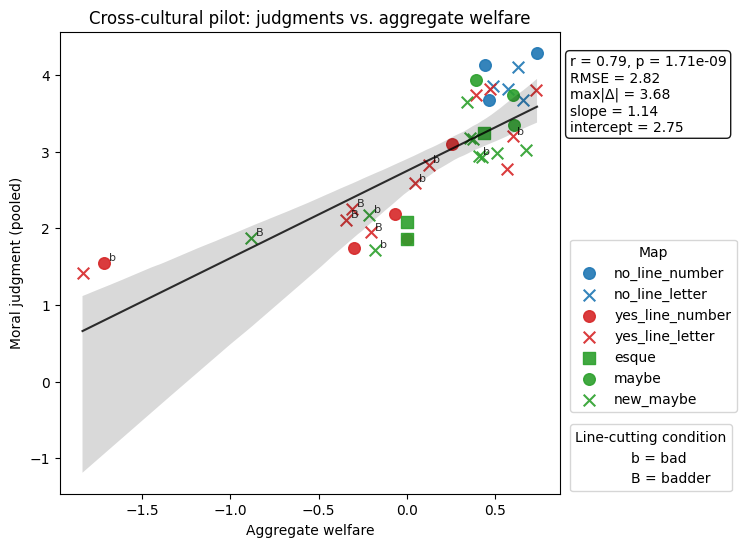

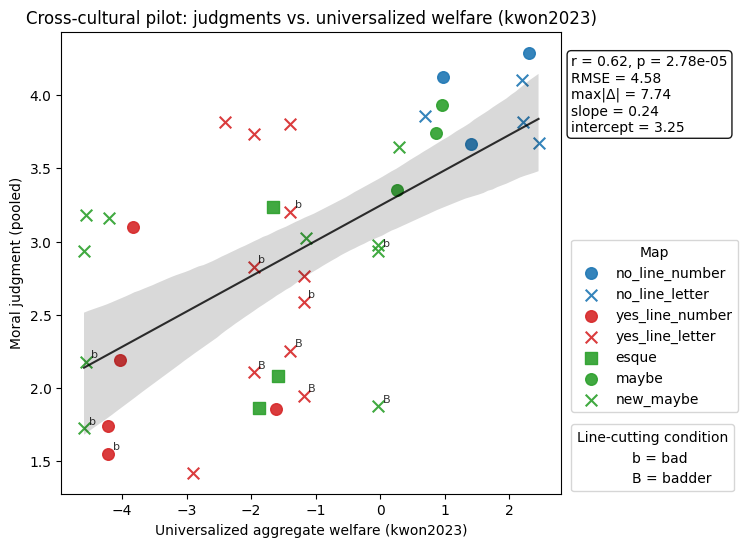

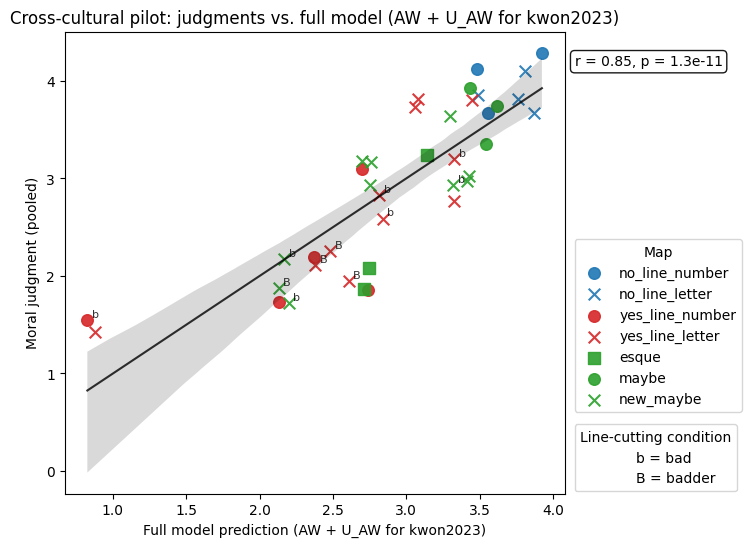

In [26]:
### --- redo for kwon

design1 = design_by_run["kwon2023"]

models_lvl0 = {}

# M0: AW
row_M0, m_M0 = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M0_AW"] = (row_M0, m_M0)

# M1: AW + U_AW
row_M1, m_M1 = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M1_AW+U_AW"] = (row_M1, m_M1)

# M2a: AW + U_AW + U_Ineq
row_M2a, m_M2a = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_inequality"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M2a_AW+U_AW+U_Ineq"] = (row_M2a, m_M2a)

# M2b: AW + U_AW + U_CH
row_M2b, m_M2b = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_cardinal_harm"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M2b_AW+U_AW+U_CH"] = (row_M2b, m_M2b)

# M2c: AW + U_AW + U_Gini
row_M2c, m_M2c = fit_ols(
    design_df=design1,
    predictors=["aggregate_welfare", "univ_aggregate_welfare", "univ_gini"],
    dv="rating_mean",
    run_type="kwon2023",
)
models_lvl0["M2c_AW+U_AW+U_Gini"] = (row_M2c, m_M2c)

# Put rows in a DataFrame
rows = []
for name, (row, model) in models_lvl0.items():
    r = row.copy()
    r["model_id"] = name
    r["logLik"] = model.llf
    rows.append(r)

tbl_lvl0 = pd.DataFrame(rows)

# Add ΔBIC relative to best
best_bic = tbl_lvl0["BIC"].min()
tbl_lvl0["delta_BIC"] = tbl_lvl0["BIC"] - best_bic

# Add LR tests:
# - M0 vs M1
# - M1 vs each M2*
tbl_lvl0["lr_ref"] = None
tbl_lvl0["lr_stat"] = None
tbl_lvl0["lr_df"] = None
tbl_lvl0["lr_p"] = None

def set_lr_row(df, model_from, model_to, ref_name):
    stat, df_lr, p = lr_test(models_lvl0[model_from][1],
                             models_lvl0[model_to][1])
    idx = df["model_id"] == model_to
    df.loc[idx, "lr_ref"] = ref_name
    df.loc[idx, "lr_stat"] = stat
    df.loc[idx, "lr_df"] = df_lr
    df.loc[idx, "lr_p"] = p

# AW vs AW+U_AW
set_lr_row(tbl_lvl0, "M0_AW", "M1_AW+U_AW", ref_name="M0_AW")

# AW+U_AW vs each 3-predictor model
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2a_AW+U_AW+U_Ineq", ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2b_AW+U_AW+U_CH",   ref_name="M1_AW+U_AW")
set_lr_row(tbl_lvl0, "M1_AW+U_AW", "M2c_AW+U_AW+U_Gini", ref_name="M1_AW+U_AW")

# For display: pick columns & order
cols = [
    "model_id",
    "predictors",           # your short labels, e.g. AW+U_AW
    "n_predictors",
    "R2",
    "adj_R2",
    "AIC",
    "BIC",
    "delta_BIC",
    "lr_ref",
    "lr_stat",
    "lr_df",
    "lr_p",
]
tbl_lvl0_display = tbl_lvl0[cols].sort_values("BIC")

# Pull out M0 row
m0 = tbl_lvl0_display[tbl_lvl0_display["model_id"] == "M0_AW"]
rest = tbl_lvl0_display[tbl_lvl0_display["model_id"] != "M0_AW"]

# Recombine with M0 first
tbl_lvl0_display = pd.concat([m0, rest], ignore_index=True)
display(tbl_lvl0_display)

# Add predictions to the design df
design1 = design1.copy()
design1["pred_M0"] = models_lvl0["M0_AW"][1].fittedvalues
design1["pred_M1"] = models_lvl0["M1_AW+U_AW"][1].fittedvalues

#AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design1,
    x_col="aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. aggregate welfare",
    xlabel="Aggregate welfare",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_AW.png",
    display_line_cutting_condition=True,
    fit_regression=True
)

#U_AW only (re-fit the regression)
fig, ax = plot_simple_regression(
    design1,
    x_col="univ_aggregate_welfare",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. universalized welfare (kwon2023)",
    xlabel="Universalized aggregate welfare (kwon2023)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_UW_kwon2023",
    display_line_cutting_condition=True,
    fit_regression=True
)

# AW + U_AW (do not refit the regressoin; just showing regrssion of y_predicted against y)
fig2, ax2 = plot_simple_regression(
    design1,
    x_col="pred_M1",
    y_col="rating_mean",
    map_col="map_name",
    title="Cross-cultural pilot: judgments vs. full model (AW + U_AW for kwon2023)",
    xlabel="Full model prediction (AW + U_AW for kwon2023)",
    ylabel="Moral judgment (pooled)",    
    save_path="figures/pilot/fit_to_full_kwon2023",
    display_line_cutting_condition=True,
    fit_regression=False
)

